## Visualizing Embedding transformer attentions

In [1]:
import argparse
import torch
import torch.nn as nn
import os
import pandas as pd
import yaml
import numpy as np
from tqdm import tqdm
from typing import List
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault
from src.model.data import BurstPrismaDataset
from src.model.net import  BurstPrisma
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from src.model.constants import get_config
from src.utils.visualization import plot_heatmap


torch.autograd.set_detect_anomaly(True)


def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

#
# Training setup.
#
config_path = "benchmark/Promoterformer/configs/default.yaml"
config = get_config(config_path)
config['masked_marks'] = []
# add_feature_bin = True
add_feature_bin = False

eid = 'E116'
remove_marks = None

if remove_marks:
    config["remove_marks"] = [remove_marks]
else:
    config["remove_marks"] = []

feature_bin_kws = config['feature_bin_kws']
seed = config["seed"]

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])  + feature_bin_kws['out_channels'] if add_feature_bin else config['promoter_feats_basic_nums'] - len(config["remove_marks"])
n_feats_pcres = config['pcres_feats_basic_nums'] 
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
pairwise_interaction_kws = config["pairwise_interaction"]
regulation_kws = config["regulation"]
d_head = config["d_head"]
targets = ['bs_label','bf_label']
npy_dir = "extra/datasets/processed/v1"

models = {}
datasets = {}
for fold in [0,1,2,3]:

    binsizes = [500]
    checkpoints = f"benchmark/Promoterformer/checkpoints/{eid}.{fold}.No_feature_bin.bs_bf_para.model.pt"


    meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"

    #
    # Setup end.
    #

    seed_everything(seed)
    meta = (
        pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
    )  # load and shuffle.

    # Split genes into two sets (train/val).
    genes = set(meta.gene_id.unique())
    n_genes = len(genes)
    print("Target genes:", len(genes))
    print(f"n_feats_p:{n_feats_p}")

    splits = {
        1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
        2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
        3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
        4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
    }

    chromosome_splits = {}
    for key, chroms in splits.items():
        for chrom in chroms:
            chromosome_splits[chrom] = key

    qs = [
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
    ]

    train_genes = (
        qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
    )
    val_genes = qs[(fold + 3) % 4]



    print(len(train_genes), len(val_genes))

    val_dataset = BurstPrismaDataset(
        meta_path,
        npy_dir,
        val_genes,
        i_max,
        binsizes,
        w_prom,
        w_max,
        config = config,
        with_gene_id=True
    )
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz, num_workers=8)

    model = BurstPrisma(
        n_feats_p,
        d_emb,
        d_head,        embed_kws=embed_kws,
        binsizes=binsizes,
        seed=42,
        targets=targets,
    ).to(DEVICE)

    ckpt = torch.load(checkpoints,map_location=DEVICE)
    model.load_state_dict(ckpt["net"])
    models[fold] = model 
    datasets[fold] = val_dataset

/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Target genes: 15420
n_feats_p:7
11691 3729
Target genes: 15420
n_feats_p:7
11245 4175
Target genes: 15420
n_feats_p:7
11624 3796
Target genes: 15420
n_feats_p:7
11700 3720


## Load Models removed H3K36me3

In [2]:
import argparse
import torch
import torch.nn as nn
import os
import pandas as pd
import yaml
import numpy as np
from tqdm import tqdm
from typing import List
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault
from src.model.data import BurstPrismaDataset
from src.model.net import  BurstPrisma
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from src.model.constants import get_config
from src.utils.visualization import plot_heatmap


torch.autograd.set_detect_anomaly(True)


def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

#
# Training setup.
#
config_path = "benchmark/Promoterformer/configs/default.yaml"
config = get_config(config_path)
# add_feature_bin = True
add_feature_bin = False

eid = 'E116'
remove_marks = "H3K36me3"

if remove_marks:
    config["remove_marks"] = [remove_marks]
else:
    config["remove_marks"] = []

feature_bin_kws = config['feature_bin_kws']
seed = config["seed"]

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])  + feature_bin_kws['out_channels'] if add_feature_bin else config['promoter_feats_basic_nums'] - len(config["remove_marks"])
n_feats_pcres = config['pcres_feats_basic_nums'] 
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
pairwise_interaction_kws = config["pairwise_interaction"]
regulation_kws = config["regulation"]
d_head = config["d_head"]
targets = ['bs_label','bf_label']
npy_dir = "extra/datasets/processed/v1"

models_without_h3k36me3 = {}
datasets_without_h3k36me3 = {}
for fold in [0,1,2,3]:

    binsizes = [500]
    checkpoints = f"benchmark/Promoterformer/checkpoints/{eid}.remove_{remove_marks}.{fold}.No_feature_bin.model.pt"


    meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"

    #
    # Setup end.
    #

    seed_everything(seed)
    meta = (
        pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
    )  # load and shuffle.

    # Split genes into two sets (train/val).
    genes = set(meta.gene_id.unique())
    n_genes = len(genes)
    print("Target genes:", len(genes))
    print(f"n_feats_p:{n_feats_p}")

    splits = {
        1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
        2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
        3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
        4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
    }

    chromosome_splits = {}
    for key, chroms in splits.items():
        for chrom in chroms:
            chromosome_splits[chrom] = key

    qs = [
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
    ]

    train_genes = (
        qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
    )
    val_genes = qs[(fold + 3) % 4]



    print(len(train_genes), len(val_genes))

    val_dataset = BurstPrismaDataset(
        meta_path,
        npy_dir,
        val_genes,
        i_max,
        binsizes,
        w_prom,
        w_max,
        config = config,
        with_gene_id=True
    )
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz, num_workers=8)

    model = BurstPrisma(
        n_feats_p,
        d_emb,
        d_head,        embed_kws=embed_kws,
        binsizes=binsizes,
        seed=42,
        targets=targets,
    ).to(DEVICE)
    model = BurstPrisma(
        n_feats_p,
        n_feats_pcres,
        d_emb,
        d_head,
        feature_bin_kws=feature_bin_kws,
        embed_kws=embed_kws,
        binsizes=binsizes,
        seed=42,
        targets=targets,
        add_feature_bin = add_feature_bin,
    ).to(DEVICE)

    ckpt = torch.load(checkpoints,map_location=DEVICE)
    model.load_state_dict(ckpt["net"])
    models_without_h3k36me3[fold] = model 
    datasets_without_h3k36me3[fold] = val_dataset

Target genes: 14304
n_feats_p:6
10819 3485
Target genes: 14304
n_feats_p:6
10449 3855
Target genes: 14304
n_feats_p:6
10790 3514
Target genes: 14304
n_feats_p:6
10854 3450


In [2]:


rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 8 ,
        'axes.titleweight' :'bold',
        'axes.titlesize': 10,  # Title font size
        
        'figure.titleweight' : 'bold' ,
        'figure.titlesize' : 8 ,
        
        'axes.labelsize' : 8 ,
        'axes.labelpad' : 2 ,
        # 'axes.labelweight' : 'bold' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'xtick.labelsize' : 7 ,
        'ytick.labelsize' : 7 ,
        
        'legend.fontsize' : 8 ,
        'figure.figsize' : (8.7/2.54, 6/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

sns.set_palette("colorblind")


## Define heatmap

In [3]:
import scipy
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import rcParamsDefault
from typing import List, Union
import pandas as pd 
import numpy as np
from matplotlib.colors import Normalize, ListedColormap,LinearSegmentedColormap


def plot_heatmap(weight_matrix,axis=None,title=None, xlabel=None,ylabel="Locations",xticks = None,xticklabels=None,yticks=None,yticklabels=None,vmin=0.2,vmax=0.4):
    """
    Plots a clustered heatmap of the weights in a given subnetwork.

    Parameters:
    weight_matrix (DataFrame): A matrix containing the weights of edges in the subnetwork.
    output_path (str): The path where the output plot will be saved.

    Returns:
    None
    """
    
    # Define colors for the heatmap
    COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]


    g = sns.heatmap(weight_matrix, 
                    cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),
                    ax=axis,
                    vmin=vmin, 
                    vmax=vmax,
                    # cbar_kws={"orientation": "horizontal"}
                )
    if xticks:
        g.set_xticks(xticks)

    if yticks:
        g.set_yticks(yticks)


    # Set the font size and name for x-axis tick labels, and rotate them for better visibility
    # g.set_xticklabels(axis.get_xticklabels(), fontsize=6, rotation=50)

    # Set the font size and name for y-axis tick labels
    # g.set_yticklabels(axis.get_yticklabels(), rotation=360)

    # Customize tick parameters for the heatmap axes
    # g.tick_params(axis='both', which='major', length=0)

    # Adjust the colorbar tick parameters if collections exist
    if g.collections:
        g.collections[0].colorbar.ax.tick_params(labelsize=6, length=1)

    # Set labels for the x-axis and y-axis
    if xlabel:
        axis.set_xlabel(xlabel)
    
    if ylabel:
        axis.set_ylabel(ylabel)

    if xticklabels:
        axis.set_xticklabels(xticklabels)

    if yticklabels:
        axis.set_yticklabels(yticklabels)

    g.set_title(title)


## Visualizing Embedding transformer attentions

### Load model and samples

### Embedding Transformer attentions visualized

### Analysis attention regions

In [4]:
def get_attention_weights(gene_id, dataset, model,binsize=500,dims=None):
    sample = dataset.get_sample(gene_id, add_bsz_dim=True)

    x = sample["promoter_feats"][binsize]
    mask = sample["promoter_pad_masks"][binsize]

    x, mask = model.generate_transformer_inputs(x, mask, binsize)
    attention_weights = np.squeeze(model.get_attention_weights(binsize,x,mask))
    if isinstance(dims,int):
        attention_weights = attention_weights[dims]
    else:
        attention_weights = np.sum(attention_weights, axis=0)
    return attention_weights

def extract_attention_regions(weights, chrom, center, strand, threshold=0.05, bin_size=500)->List[str]:
    if strand == '-':
        weights = np.flip(weights)

    def _distance_to_tss(location):
        return bin_size*(location-40)  # 第40个bin 以TSS 作为起点所在bin

    regions = []
    region = []
    for idx, weight in enumerate(weights):
        if weight > threshold:
            region.append(idx)
        else:
            if region:
                regions.append(region)
                region = []
    if region:
        regions.append(region)
    
    genomic_regions = []
    for region in regions:
        start = center + _distance_to_tss(region[0])
        end =  center + _distance_to_tss(region[-1]+1)
        genomic_regions.append(f"{chrom}:{start}-{end}")

    return genomic_regions

In [15]:
LABEL_BIN_MAP = {
    "Low bs and low bf":"C1",
    "High bs and low bf":"C2",
    "Low bs and high bf":"C3",
    "High bs and high bf":"C4",
}
data = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/predictions_bs_bf.csv')
data = data[data['eid']==eid]
data = pd.merge(data,meta[['gene_id','chrom','start','strand']],how='inner',on='gene_id').sort_values(by='bf_label_score',ascending=False)
data.head(20)



,gene_id,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,fold,eid,chrom,start,strand
14362,ENSG00000186812,0,0.533300,1,1,0.998623,1,3,E116,chr18,32820996,+
14938,ENSG00000036257,1,0.762895,1,1,0.998058,1,3,E116,chr2,225450114,-
14686,ENSG00000163320,1,0.890952,1,1,0.997674,1,3,E116,chr3,88108155,-
13412,ENSG00000135999,0,0.514023,1,1,0.997651,1,3,E116,chr2,149402318,+
12085,ENSG00000163960,1,0.864794,1,1,0.997507,1,3,E116,chr3,196159298,-
12108,ENSG00000169967,0,0.658987,1,1,0.997411,1,3,E116,chr2,128145551,-
13326,ENSG00000172086,1,0.857549,1,1,0.997334,1,3,E116,chr2,88355302,-
13830,ENSG00000103018,1,0.727764,1,1,0.997285,1,3,E116,chr16,69458520,+
14248,ENSG00000164134,1,0.690775,1,1,0.997110,1,3,E116,chr4,140222657,+
12357,ENSG00000132394,1,0.688097,1,1,0.996802,1,3,E116,chr3,127872322,+


## Attention Case Analysis

### Low bs and high bf

100%|██████████| 1/1 [00:00<00:00, 15.55it/s]


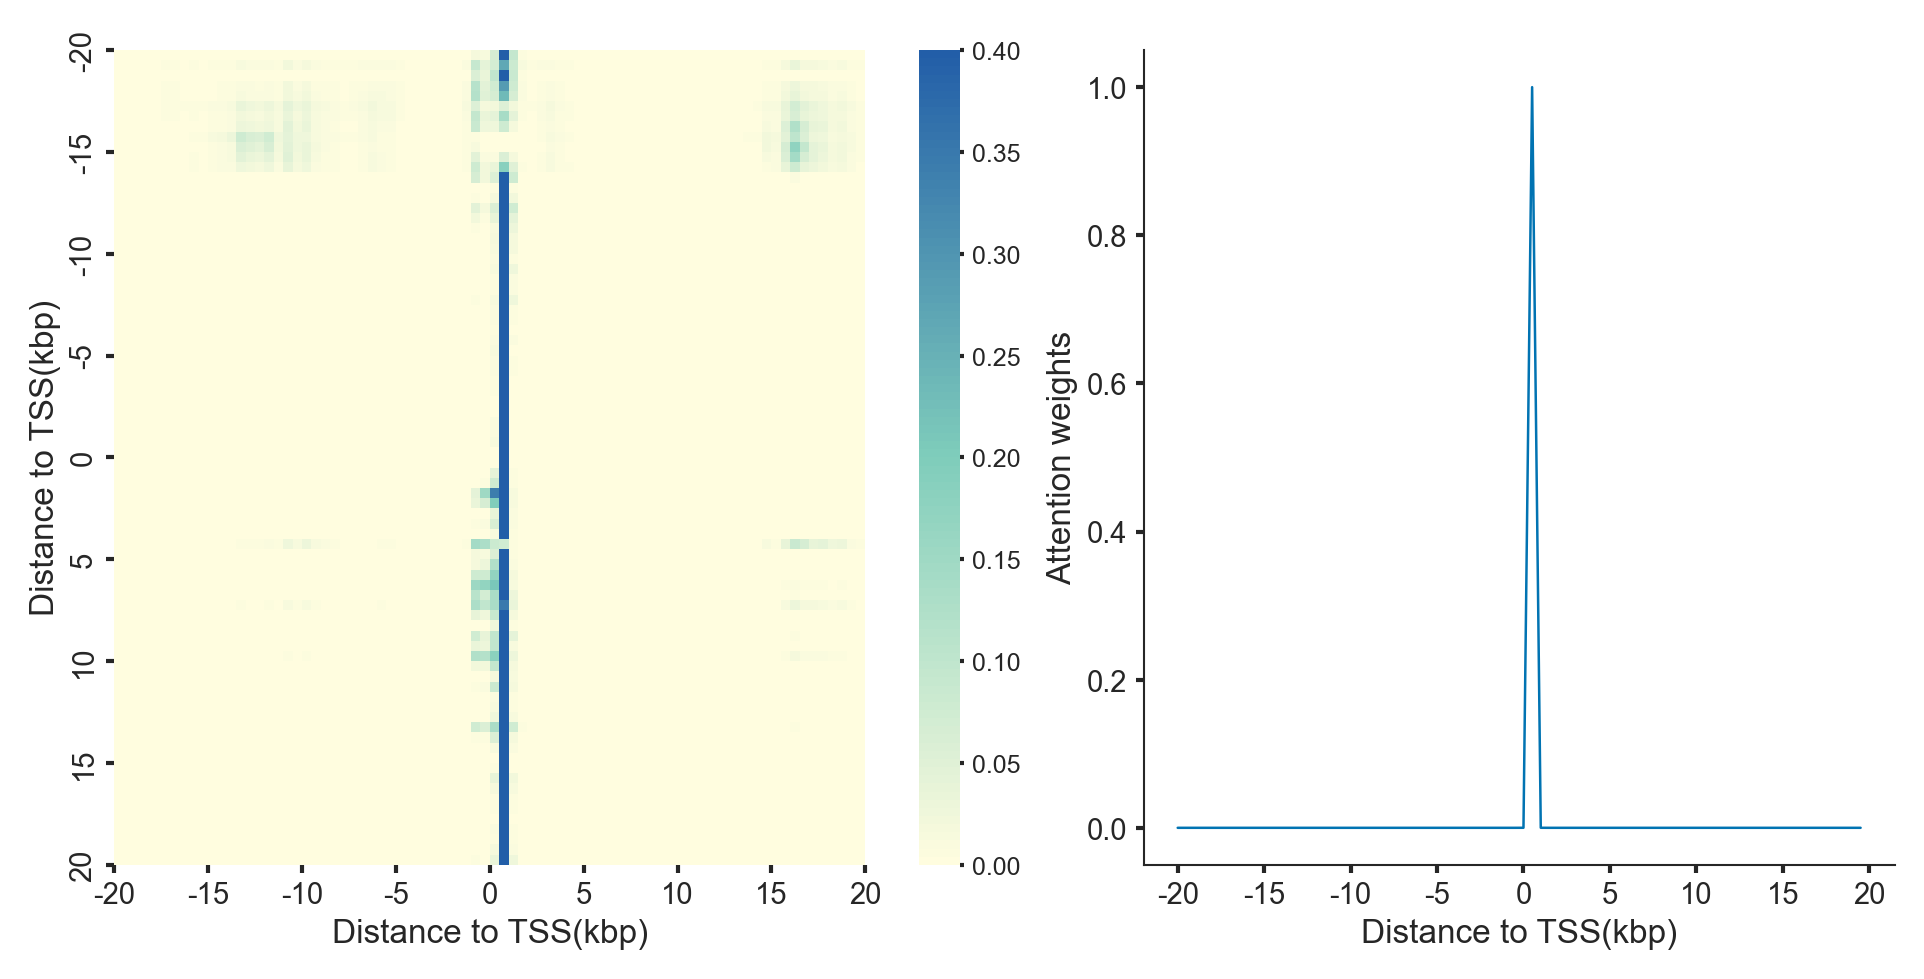

In [17]:
high_gene_ids = data[(data['bf_label_label']==1) & (data['gene_id']=='ENSG00000175390')]

# samples = [datasets[record['fold']].get_sample(record['gene_id'], add_bsz_dim=True) for record in high_gene_ids.to_records()]
dims = 0
attention_weights = 0
gene_ids = high_gene_ids
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    attention_weights += get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=dims)

attention_weights = attention_weights/len(gene_ids)

attention_distribution = np.mean(attention_weights, axis=0)
attention_distribution = attention_weights[40,:]

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16/2.54, 8/2.54))

xticks = [i for i in range(0,81,10)]
yticks = [i for i in range(0,81,10)]
xticklabels = [int((i-40)/2) for i in range(0,81,10)]
yticklabels = [int((i-40)/2) for i in range(0,81,10)]
plot_heatmap(
    attention_weights,axis=ax[0],
    xticks=xticks,
    yticks=yticks,
    xticklabels=xticklabels,
    yticklabels=yticklabels,
    xlabel="Distance to TSS(kbp)",
    ylabel="Distance to TSS(kbp)",
    vmin=0.0,
)


sns.lineplot(attention_distribution,lw=0.6, label='Feature Importance',ax=ax[1])
ax[1].set_ylabel("Attention weights")
ax[1].set_xlabel("Distance to TSS(kbp)")
ax[1].legend().remove()
ax[1].set_xticks(xticks)
ax[1].set_xticklabels(xticklabels)

plt.show()





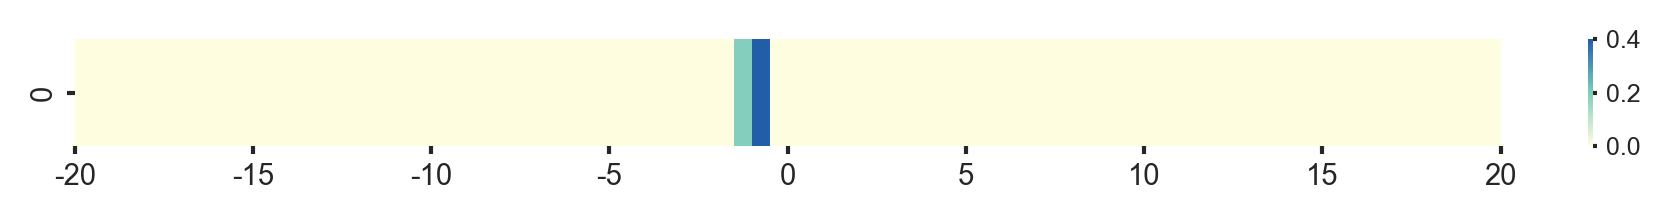

In [28]:
# sns.heatmap(np.flip(attention_weights[40:41,:]))

fig, ax =plt.subplots(1,1,constrained_layout=True, figsize=(14/2.54, 1.5/2.54))

xticks = [i for i in range(0,81,10)]
yticks = [i for i in range(0,81,10)]
xticklabels = [int((i-40)/2) for i in range(0,81,10)]
# yticklabels = [int((i-40)/2) for i in range(0,81,10)]
plot_heatmap(
    np.flip(attention_weights[39:40,:]),axis=ax,
    xticks=xticks,
    # yticks=yticks,
    xticklabels=xticklabels,
    # yticklabels=yticklabels,
    xlabel="",
    ylabel="",
    vmin=0.0,
)
# plt.savefig('extra/datasets/benchmark/Promoterformer/figures/v6/Figure4F_1.eps', format='eps', bbox_inches='tight')



In [26]:
np.mean(attention_weights[39:41,:],axis=0)

array([1.16993965e-18, 1.32401752e-23, 1.42483956e-22, 3.58085609e-25,
       4.12216185e-26, 2.11576907e-21, 4.87765749e-21, 1.35065104e-21,
       3.02695436e-21, 9.01920450e-23, 9.08061044e-22, 1.50904500e-23,
       1.29731081e-21, 2.05522151e-21, 8.06872887e-24, 1.82222073e-21,
       2.10265422e-22, 1.25127973e-24, 8.19781779e-22, 5.90417521e-25,
       3.25783402e-24, 2.38644156e-22, 2.32326923e-21, 1.29380244e-22,
       1.11668039e-19, 1.53871120e-20, 5.75498075e-23, 5.57539482e-19,
       8.66377168e-16, 1.62596053e-15, 7.10653194e-12, 2.98424832e-13,
       1.91374203e-14, 6.61328485e-08, 5.47820400e-10, 2.05845367e-07,
       2.68873830e-08, 3.86731961e-04, 3.36941844e-03, 8.59907805e-12,
       1.50316495e-11, 8.03602695e-01, 1.92210346e-01, 4.30531974e-04,
       1.68963815e-10, 3.80113362e-15, 1.36573615e-17, 3.28983352e-19,
       1.54324471e-18, 8.15051441e-22, 5.00987108e-20, 2.00366874e-19,
       2.62927592e-22, 9.45397465e-22, 3.80241971e-20, 1.45485198e-18,
      

In [11]:
high_gene_ids

,gene_id,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,fold,eid,chrom,start,strand
14686,ENSG00000163320,1,0.890952,1,1,0.997674,1,3,E116,chr3,88108155,-


100%|██████████| 1/1 [00:00<00:00, 13.39it/s]


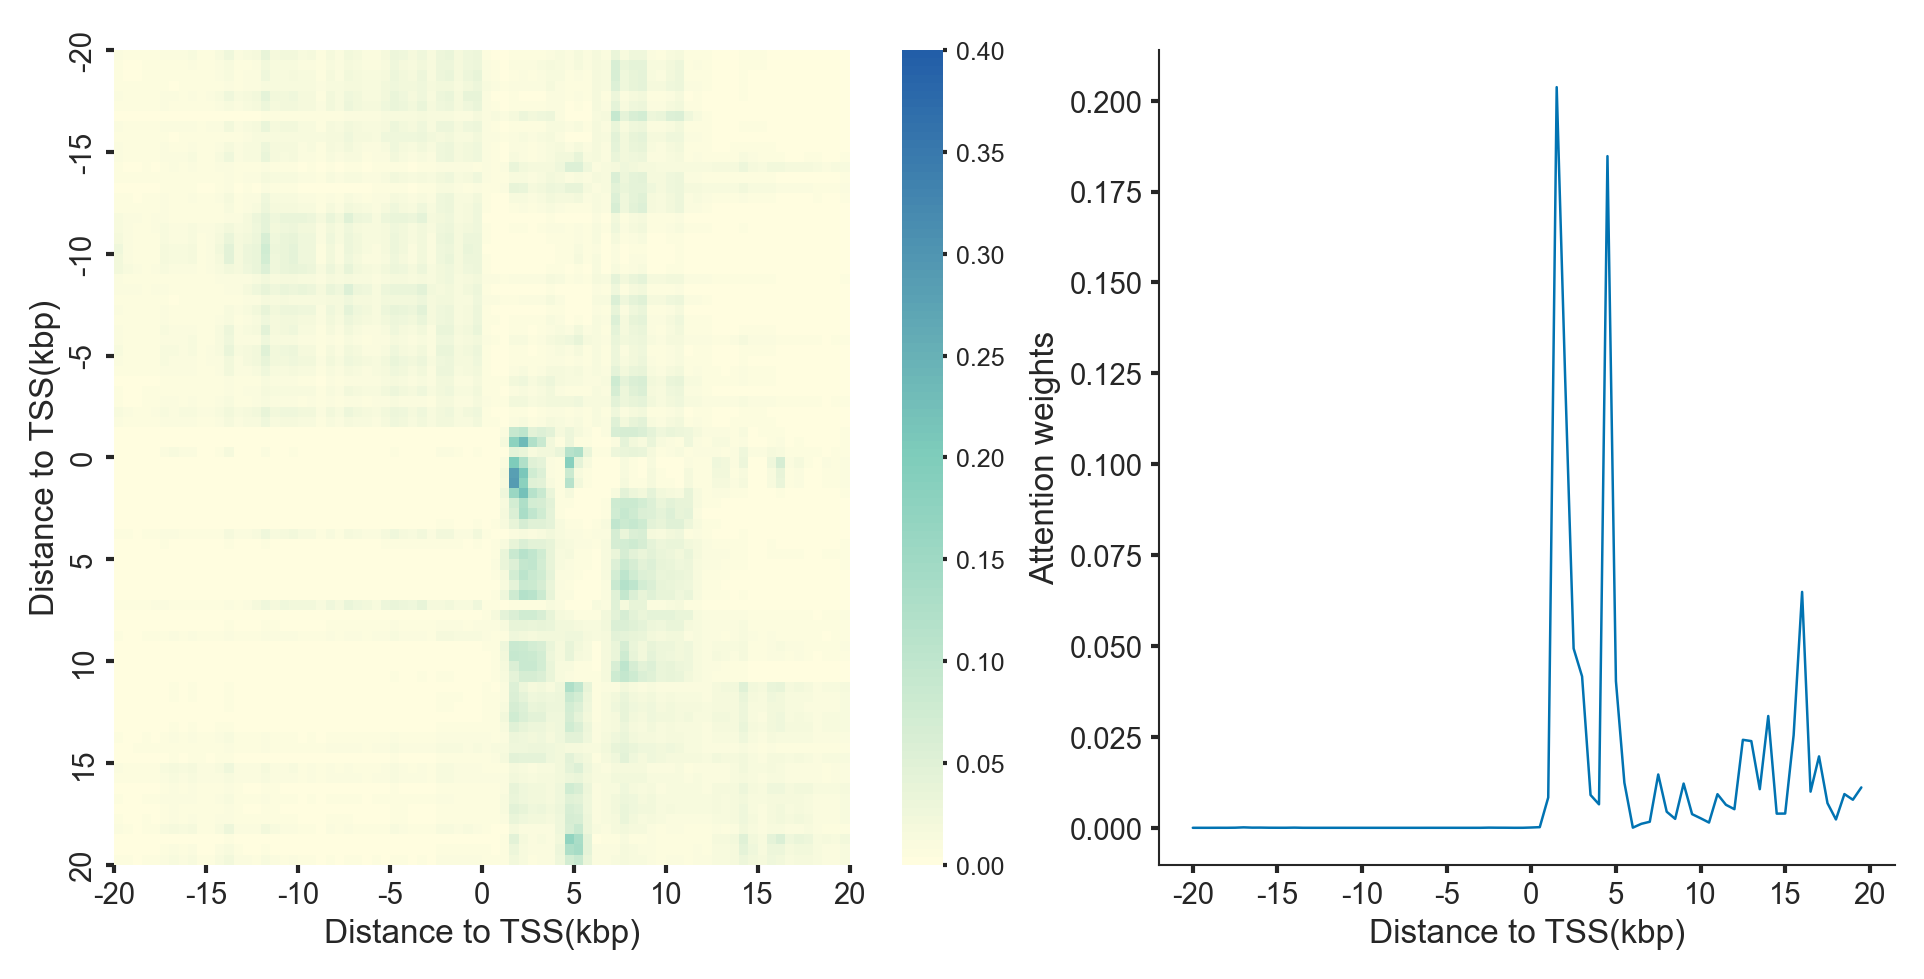

In [8]:
high_gene_ids = data[(data['bf_label_label']==1) & (data['gene_id']=='ENSG00000155660')]

# samples = [datasets[record['fold']].get_sample(record['gene_id'], add_bsz_dim=True) for record in high_gene_ids.to_records()]
dims=1
attention_weights = 0
gene_ids = high_gene_ids
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    attention_weights += get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=dims)

attention_weights = attention_weights/len(gene_ids)

# attention_distribution = np.mean(attention_weights, axis=0)
attention_distribution = attention_weights[40,:]

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16/2.54, 8/2.54))

xticks = [i for i in range(0,81,10)]
yticks = [i for i in range(0,81,10)]
xticklabels = [int((i-40)/2) for i in range(0,81,10)]
yticklabels = [int((i-40)/2) for i in range(0,81,10)]
plot_heatmap(
    attention_weights,axis=ax[0],
    xticks=xticks,
    yticks=yticks,
    xticklabels=xticklabels,
    yticklabels=yticklabels,
    xlabel="Distance to TSS(kbp)",
    ylabel="Distance to TSS(kbp)",
    vmin=0
)


sns.lineplot(attention_distribution,lw=0.6, label='Feature Importance',ax=ax[1])
ax[1].set_ylabel("Attention weights")
ax[1].set_xlabel("Distance to TSS(kbp)")
ax[1].legend().remove()
ax[1].set_xticks(xticks)
ax[1].set_xticklabels(xticklabels)

plt.show()





100%|██████████| 2439/2439 [00:28<00:00, 86.88it/s]


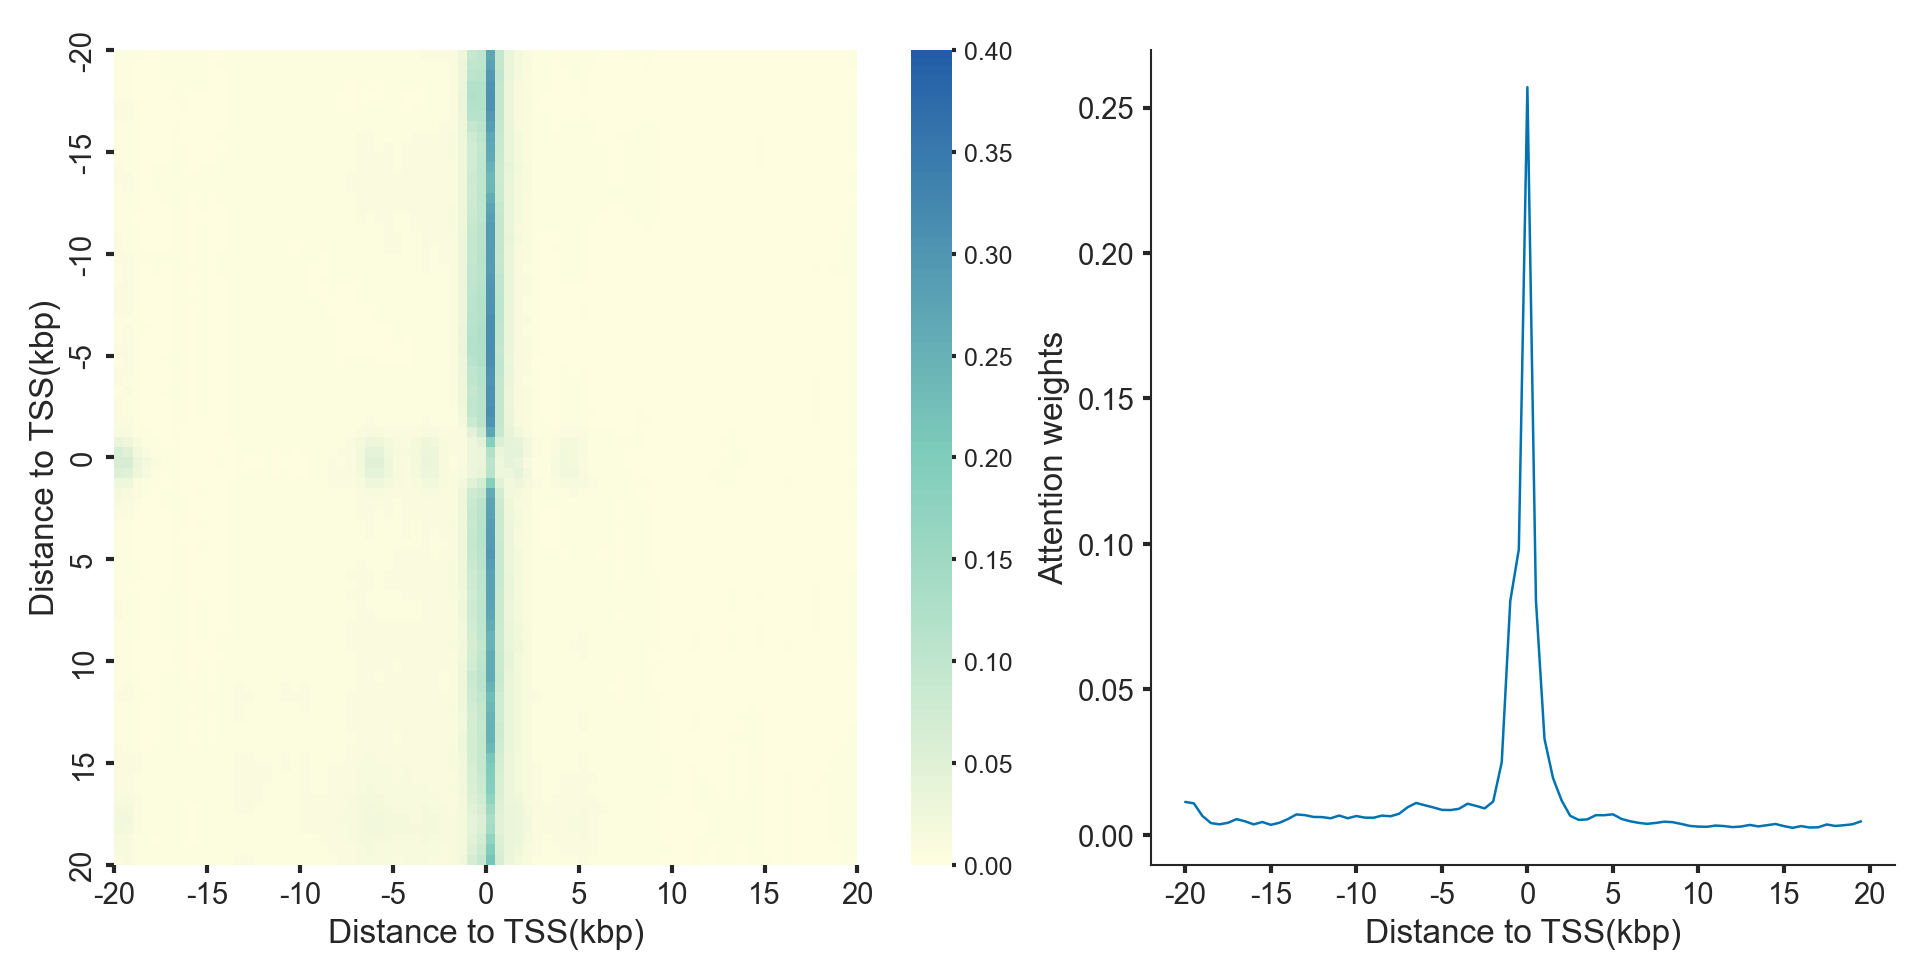

In [8]:
high_gene_ids = data[(data['labels_marks']==LABEL_BIN_MAP['Low bs and high bf']) ]

# samples = [datasets[record['fold']].get_sample(record['gene_id'], add_bsz_dim=True) for record in high_gene_ids.to_records()]

attention_weights = 0
gene_ids = high_gene_ids
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    attention_weights += get_attention_weights(gene_id, datasets_without_h3k36me3[fold], models_without_h3k36me3[fold], binsize=binsizes[0],dims=dims)

attention_weights = attention_weights/len(gene_ids)

attention_distribution = np.mean(attention_weights, axis=0)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16/2.54, 8/2.54))

xticks = [i for i in range(0,81,10)]
yticks = [i for i in range(0,81,10)]
xticklabels = [int((i-40)/2) for i in range(0,81,10)]
yticklabels = [int((i-40)/2) for i in range(0,81,10)]
plot_heatmap(
    attention_weights,axis=ax[0],
    xticks=xticks,
    yticks=yticks,
    xticklabels=xticklabels,
    yticklabels=yticklabels,
    xlabel="Distance to TSS(kbp)",
    ylabel="Distance to TSS(kbp)",
)


sns.lineplot(attention_distribution,lw=0.6, label='Feature Importance',ax=ax[1])
ax[1].set_ylabel("Attention weights")
ax[1].set_xlabel("Distance to TSS(kbp)")
ax[1].legend().remove()
ax[1].set_xticks(xticks)
ax[1].set_xticklabels(xticklabels)

plt.show()



### Low bs and low bf

100%|██████████| 4716/4716 [00:57<00:00, 81.93it/s]


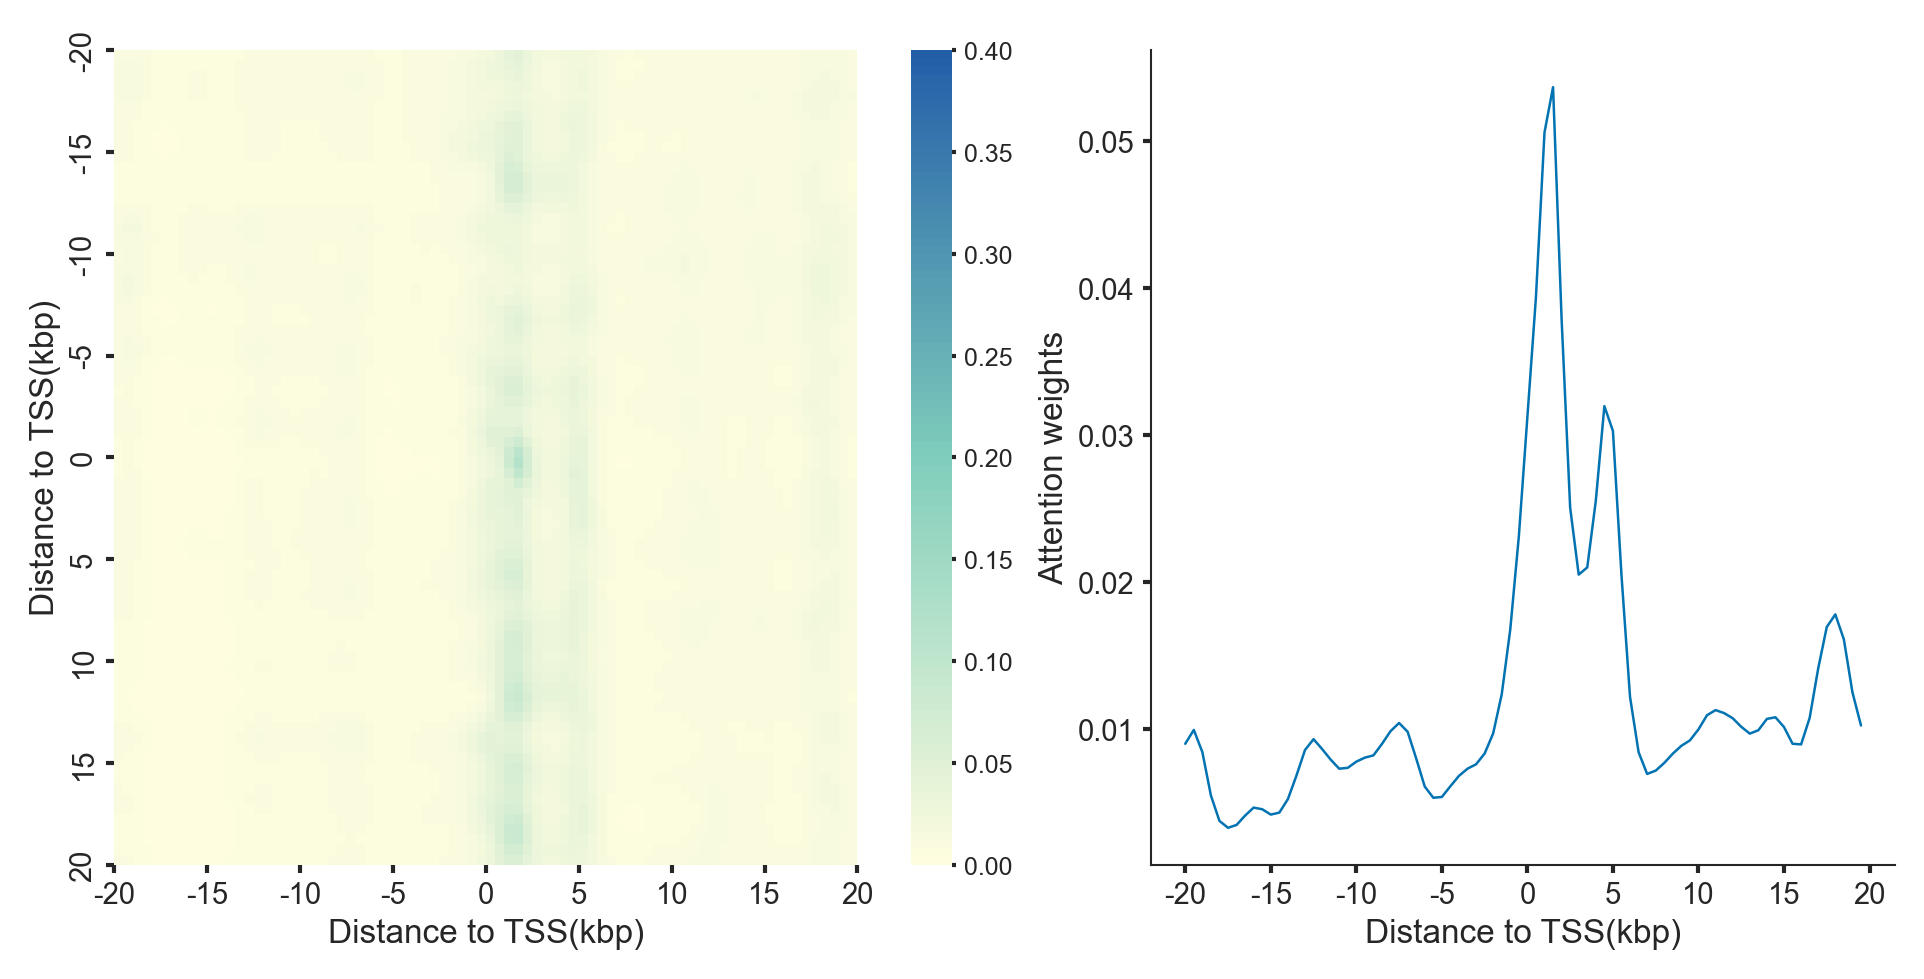

In [9]:
high_gene_ids = data[data['labels_marks']==LABEL_BIN_MAP['Low bs and low bf']]

attention_weights = 0
gene_ids = high_gene_ids
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    attention_weights += get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=dims)

attention_weights = attention_weights/len(gene_ids)

attention_distribution = np.mean(attention_weights, axis=0)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16/2.54, 8/2.54))

xticks = [i for i in range(0,81,10)]
yticks = [i for i in range(0,81,10)]
xticklabels = [int((i-40)/2) for i in range(0,81,10)]
yticklabels = [int((i-40)/2) for i in range(0,81,10)]
plot_heatmap(
    attention_weights,axis=ax[0],
    xticks=xticks,
    yticks=yticks,
    xticklabels=xticklabels,
    yticklabels=yticklabels,
    xlabel="Distance to TSS(kbp)",
    ylabel="Distance to TSS(kbp)",
)


sns.lineplot(attention_distribution,lw=0.6, label='Feature Importance',ax=ax[1])
ax[1].set_ylabel("Attention weights")
ax[1].set_xlabel("Distance to TSS(kbp)")
ax[1].legend().remove()
ax[1].set_xticks(xticks)
ax[1].set_xticklabels(xticklabels)

plt.show()


100%|██████████| 4716/4716 [00:52<00:00, 89.59it/s]


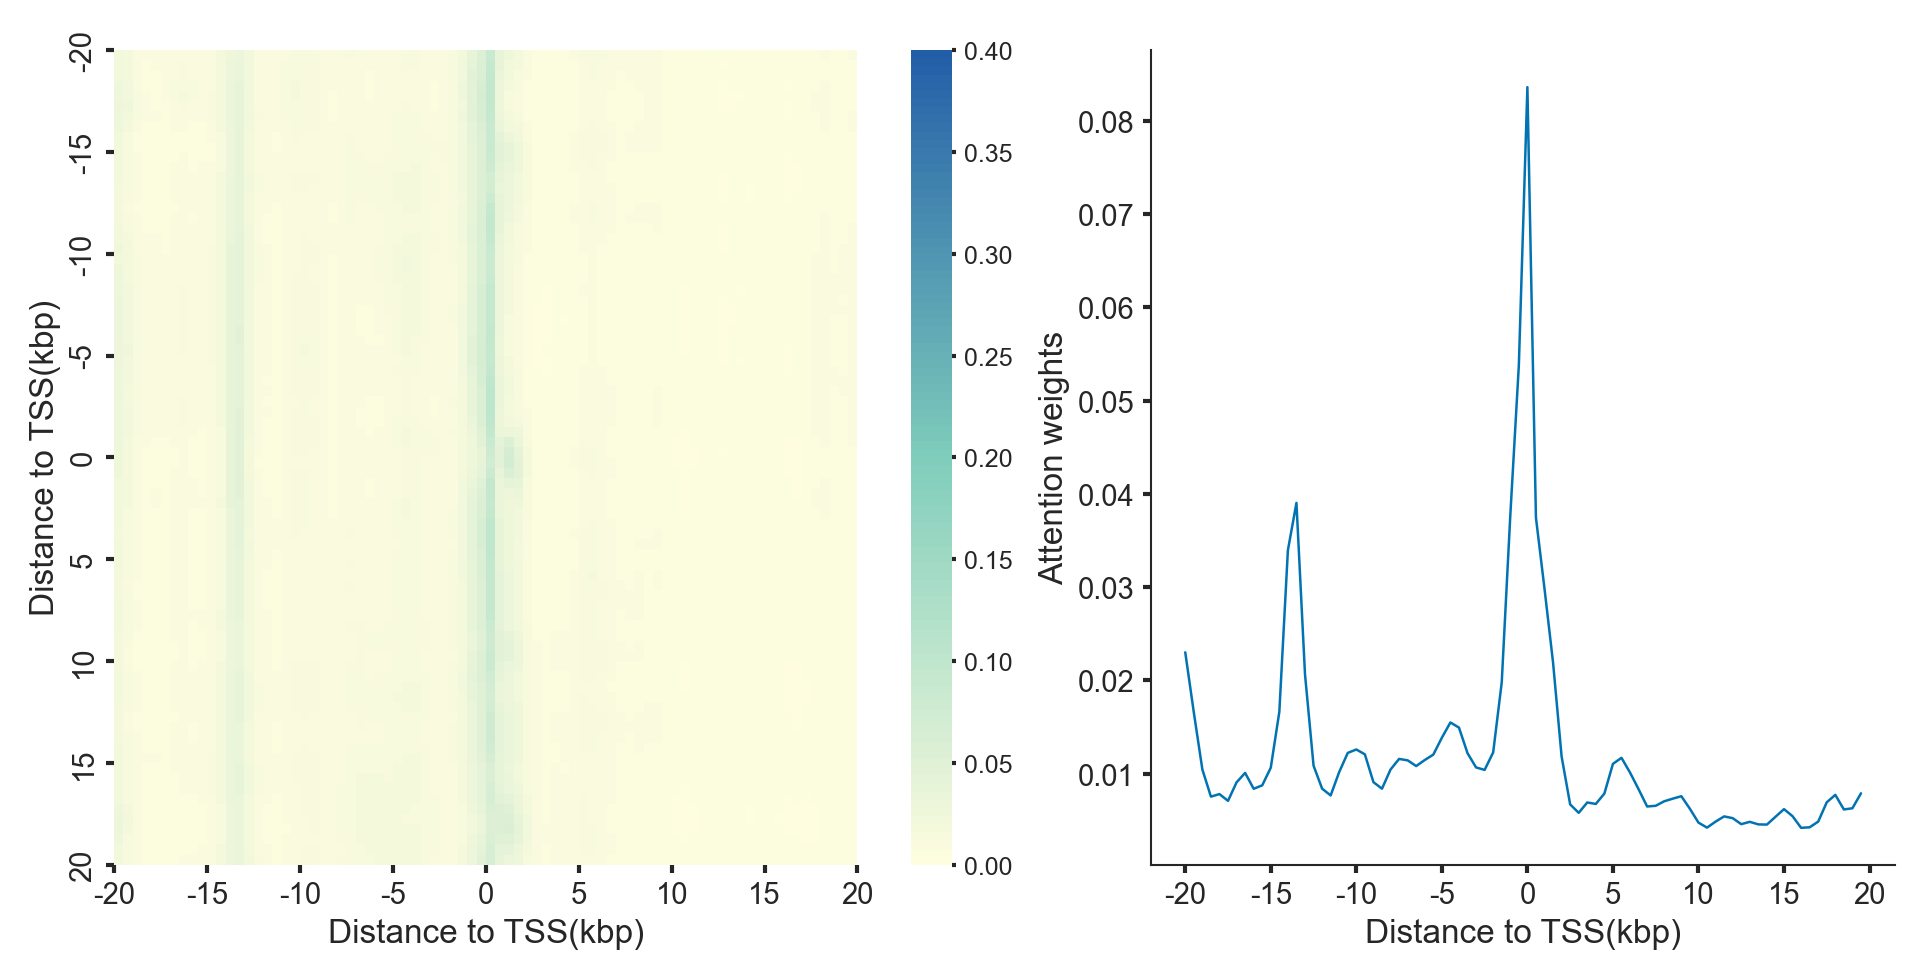

In [10]:
high_gene_ids = data[(data['labels_marks']==LABEL_BIN_MAP['Low bs and low bf']) ]

# samples = [datasets[record['fold']].get_sample(record['gene_id'], add_bsz_dim=True) for record in high_gene_ids.to_records()]

attention_weights = 0
gene_ids = high_gene_ids
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    attention_weights += get_attention_weights(gene_id, datasets_without_h3k36me3[fold], models_without_h3k36me3[fold], binsize=binsizes[0],dims=dims)

attention_weights = attention_weights/len(gene_ids)

attention_distribution = np.mean(attention_weights, axis=0)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16/2.54, 8/2.54))

xticks = [i for i in range(0,81,10)]
yticks = [i for i in range(0,81,10)]
xticklabels = [int((i-40)/2) for i in range(0,81,10)]
yticklabels = [int((i-40)/2) for i in range(0,81,10)]
plot_heatmap(
    attention_weights,axis=ax[0],
    xticks=xticks,
    yticks=yticks,
    xticklabels=xticklabels,
    yticklabels=yticklabels,
    xlabel="Distance to TSS(kbp)",
    ylabel="Distance to TSS(kbp)",
)


sns.lineplot(attention_distribution,lw=0.6, label='Feature Importance',ax=ax[1])
ax[1].set_ylabel("Attention weights")
ax[1].set_xlabel("Distance to TSS(kbp)")
ax[1].legend().remove()
ax[1].set_xticks(xticks)
ax[1].set_xticklabels(xticklabels)

plt.show()



### High bs and low bf

100%|██████████| 2434/2434 [00:27<00:00, 87.03it/s]


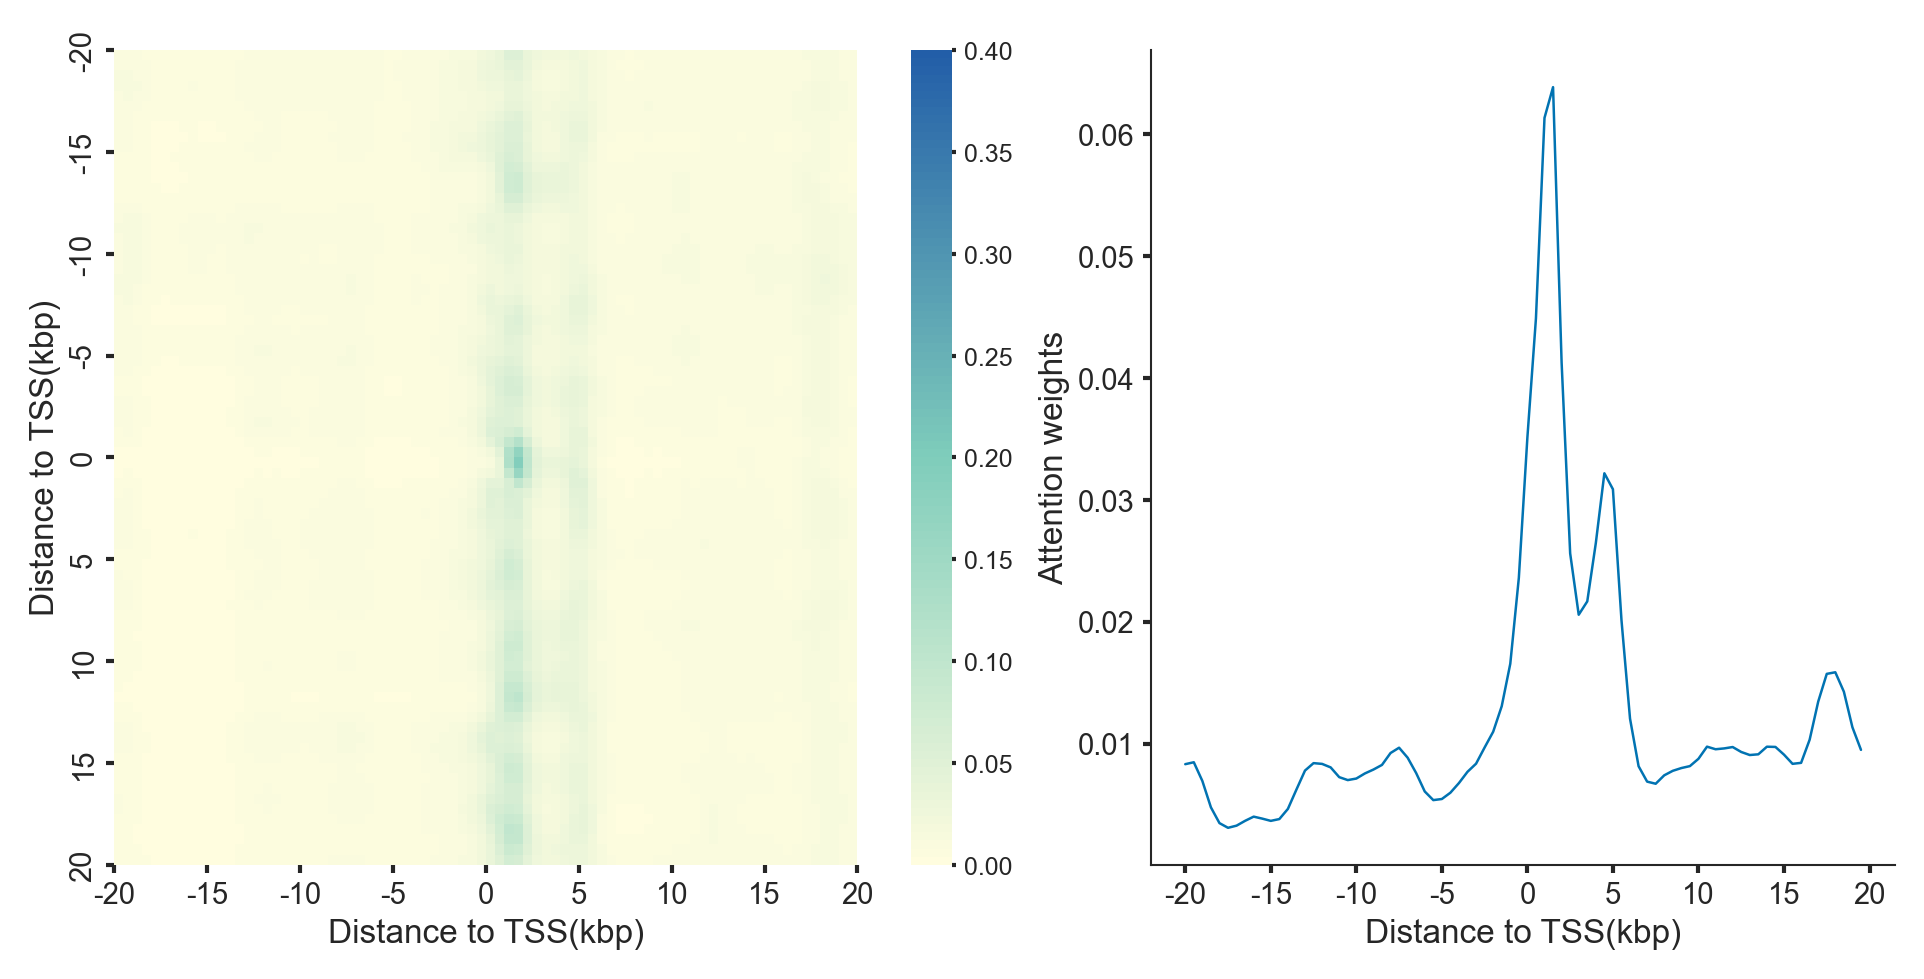

In [11]:
high_gene_ids = data[data['labels_marks']==LABEL_BIN_MAP['High bs and low bf']]

attention_weights = 0
gene_ids = high_gene_ids
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    attention_weights += get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=dims)

attention_weights = attention_weights/len(gene_ids)

attention_distribution = np.mean(attention_weights, axis=0)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16/2.54, 8/2.54))

xticks = [i for i in range(0,81,10)]
yticks = [i for i in range(0,81,10)]
xticklabels = [int((i-40)/2) for i in range(0,81,10)]
yticklabels = [int((i-40)/2) for i in range(0,81,10)]
plot_heatmap(
    attention_weights,axis=ax[0],
    xticks=xticks,
    yticks=yticks,
    xticklabels=xticklabels,
    yticklabels=yticklabels,
    xlabel="Distance to TSS(kbp)",
    ylabel="Distance to TSS(kbp)",
)


sns.lineplot(attention_distribution,lw=0.6, label='Feature Importance',ax=ax[1])
ax[1].set_ylabel("Attention weights")
ax[1].set_xlabel("Distance to TSS(kbp)")
ax[1].legend().remove()
ax[1].set_xticks(xticks)
ax[1].set_xticklabels(xticklabels)

plt.show()



100%|██████████| 2434/2434 [00:26<00:00, 91.60it/s]


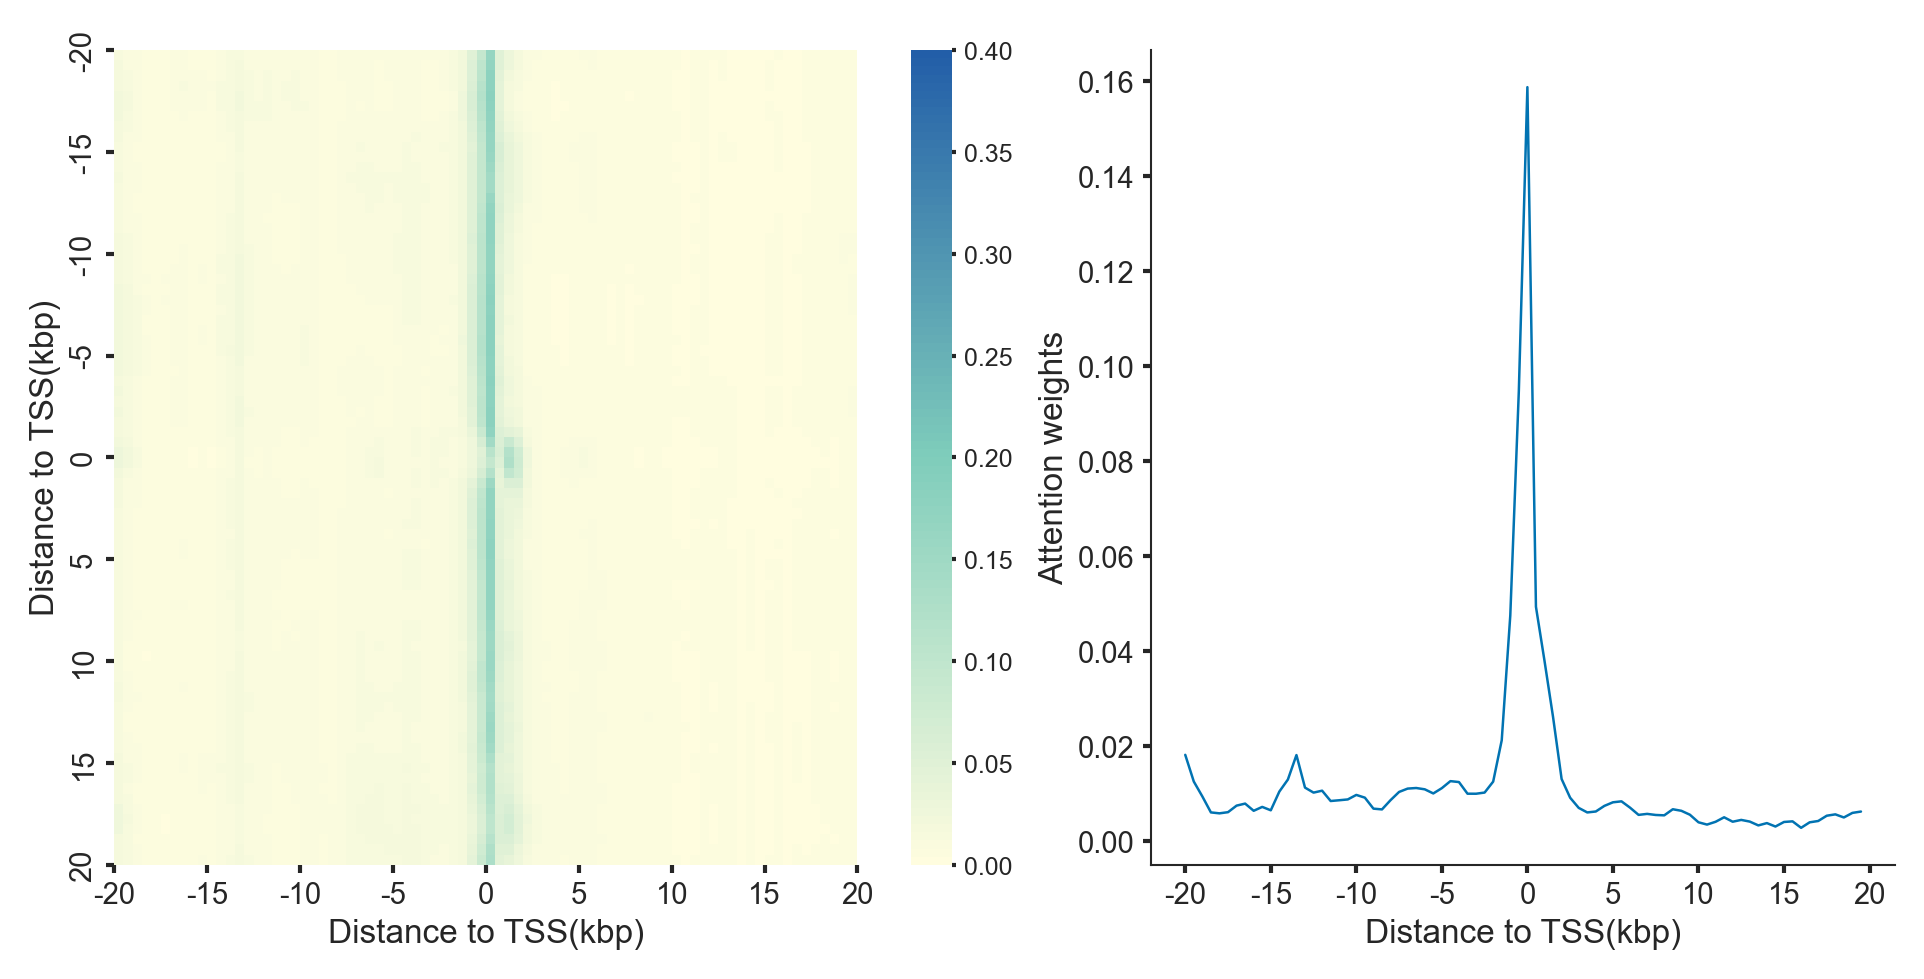

In [12]:
high_gene_ids = data[(data['labels_marks']==LABEL_BIN_MAP['High bs and low bf']) ]

# samples = [datasets[record['fold']].get_sample(record['gene_id'], add_bsz_dim=True) for record in high_gene_ids.to_records()]

attention_weights = 0
gene_ids = high_gene_ids
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    attention_weights += get_attention_weights(gene_id, datasets_without_h3k36me3[fold], models_without_h3k36me3[fold], binsize=binsizes[0],dims=dims)

attention_weights = attention_weights/len(gene_ids)

attention_distribution = np.mean(attention_weights, axis=0)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16/2.54, 8/2.54))

xticks = [i for i in range(0,81,10)]
yticks = [i for i in range(0,81,10)]
xticklabels = [int((i-40)/2) for i in range(0,81,10)]
yticklabels = [int((i-40)/2) for i in range(0,81,10)]
plot_heatmap(
    attention_weights,axis=ax[0],
    xticks=xticks,
    yticks=yticks,
    xticklabels=xticklabels,
    yticklabels=yticklabels,
    xlabel="Distance to TSS(kbp)",
    ylabel="Distance to TSS(kbp)",
)


sns.lineplot(attention_distribution,lw=0.6, label='Feature Importance',ax=ax[1])
ax[1].set_ylabel("Attention weights")
ax[1].set_xlabel("Distance to TSS(kbp)")
ax[1].legend().remove()
ax[1].set_xticks(xticks)
ax[1].set_xticklabels(xticklabels)

plt.show()


### High bs and high bf

100%|██████████| 4715/4715 [00:54<00:00, 86.31it/s]


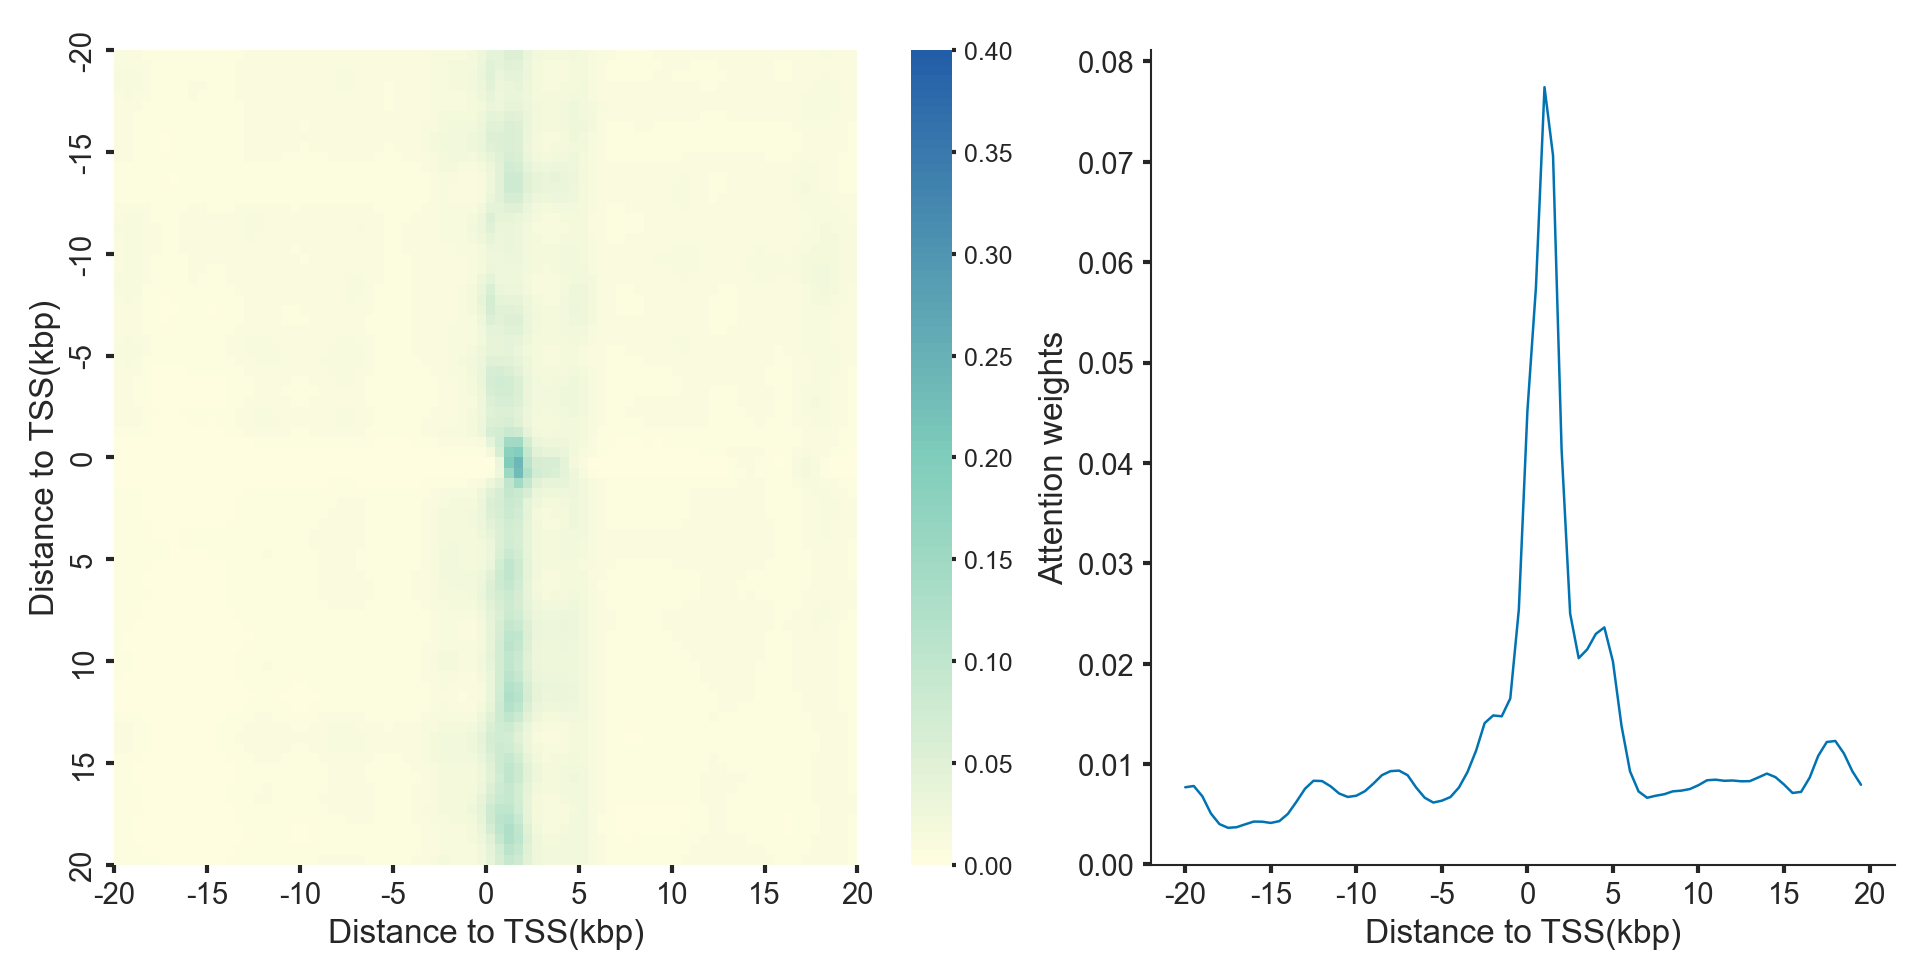

In [13]:
high_gene_ids = data[data['labels_marks']==LABEL_BIN_MAP['High bs and high bf']]

attention_weights = 0
gene_ids = high_gene_ids
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    attention_weights += get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=dims)

attention_weights = attention_weights/len(gene_ids)

attention_distribution = np.mean(attention_weights, axis=0)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16/2.54, 8/2.54))

xticks = [i for i in range(0,81,10)]
yticks = [i for i in range(0,81,10)]
xticklabels = [int((i-40)/2) for i in range(0,81,10)]
yticklabels = [int((i-40)/2) for i in range(0,81,10)]
plot_heatmap(
    attention_weights,axis=ax[0],
    xticks=xticks,
    yticks=yticks,
    xticklabels=xticklabels,
    yticklabels=yticklabels,
    xlabel="Distance to TSS(kbp)",
    ylabel="Distance to TSS(kbp)",
)


sns.lineplot(attention_distribution,lw=0.6, label='Feature Importance',ax=ax[1])
ax[1].set_ylabel("Attention weights")
ax[1].set_xlabel("Distance to TSS(kbp)")
ax[1].legend().remove()
ax[1].set_xticks(xticks)
ax[1].set_xticklabels(xticklabels)

plt.show()




100%|██████████| 4715/4715 [00:53<00:00, 87.79it/s]


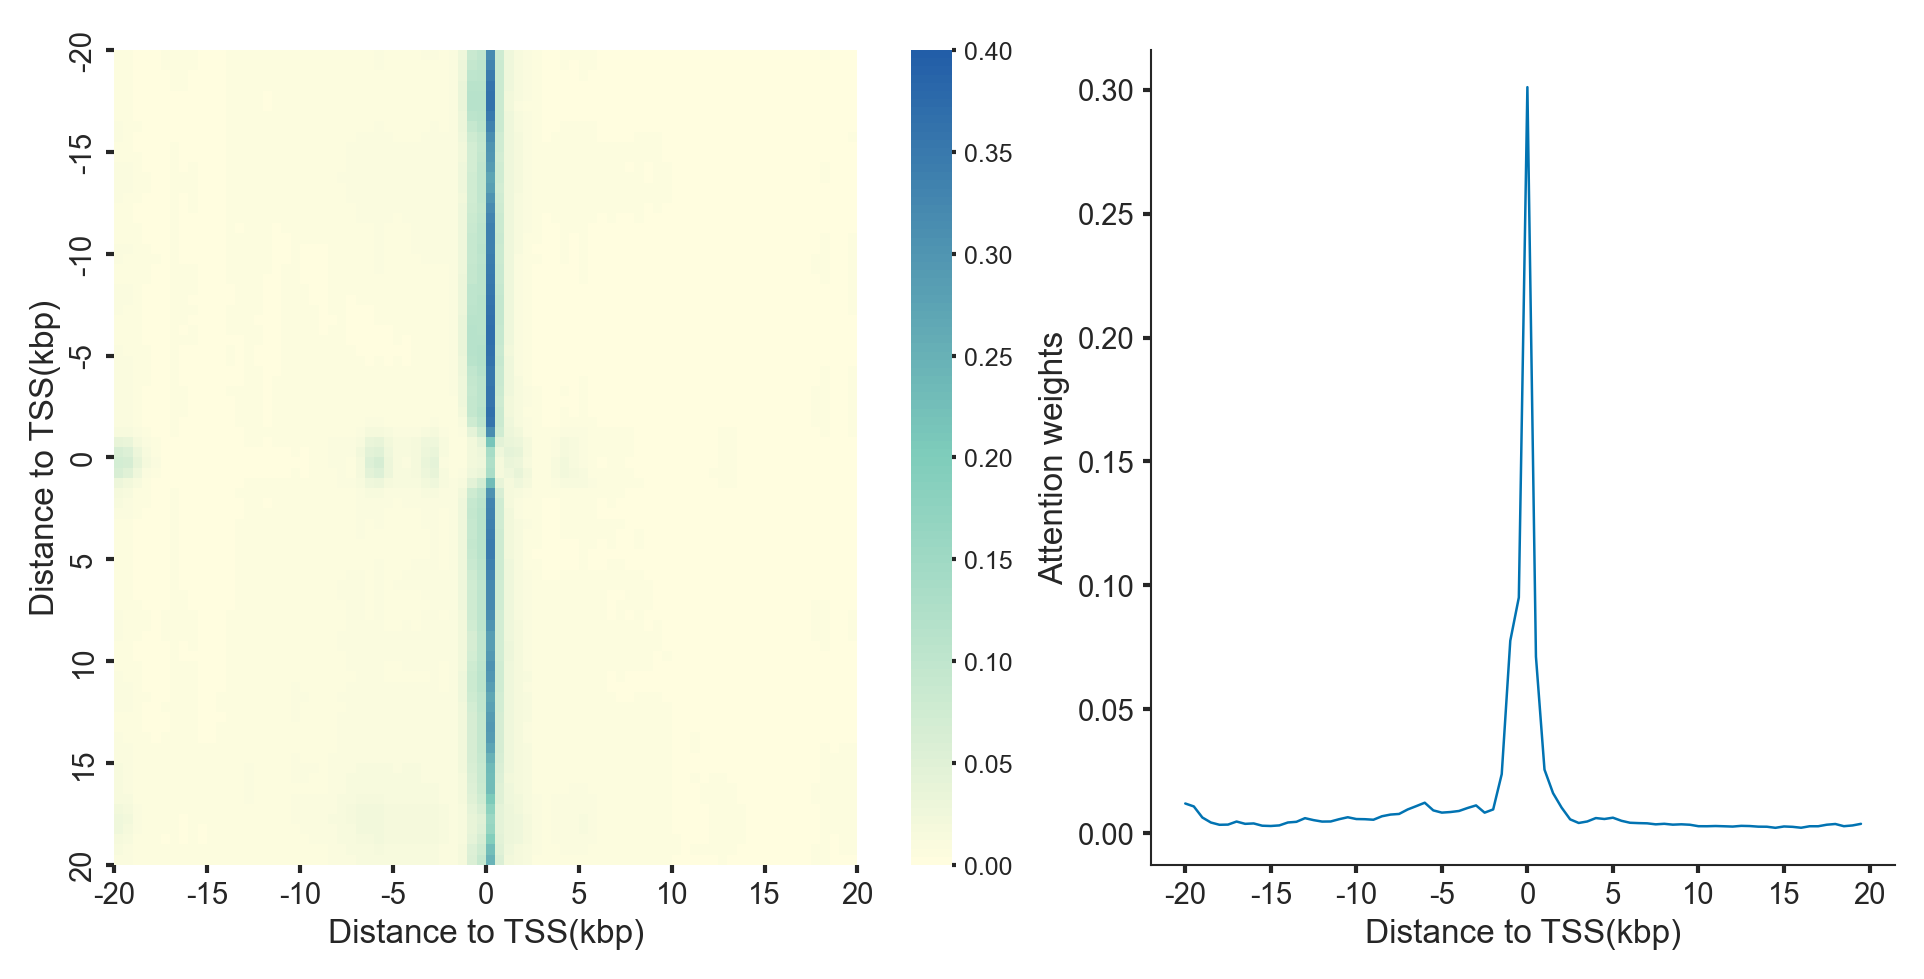

In [14]:
high_gene_ids = data[(data['labels_marks']==LABEL_BIN_MAP['High bs and high bf']) ]

attention_weights = 0
gene_ids = high_gene_ids
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    attention_weights += get_attention_weights(gene_id, datasets_without_h3k36me3[fold], models_without_h3k36me3[fold], binsize=binsizes[0],dims=dims)

attention_weights = attention_weights/len(gene_ids)

attention_distribution = np.mean(attention_weights, axis=0)
fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16/2.54, 8/2.54))

xticks = [i for i in range(0,81,10)]
yticks = [i for i in range(0,81,10)]
xticklabels = [int((i-40)/2) for i in range(0,81,10)]
yticklabels = [int((i-40)/2) for i in range(0,81,10)]
plot_heatmap(
    attention_weights,axis=ax[0],
    xticks=xticks,
    yticks=yticks,
    xticklabels=xticklabels,
    yticklabels=yticklabels,
    xlabel="Distance to TSS(kbp)",
    ylabel="Distance to TSS(kbp)",
)


sns.lineplot(attention_distribution,lw=0.6, label='Feature Importance',ax=ax[1])
ax[1].set_ylabel("Attention weights")
ax[1].set_xlabel("Distance to TSS(kbp)")
ax[1].legend().remove()
ax[1].set_xticks(xticks)
ax[1].set_xticklabels(xticklabels)

plt.show()



### ALL datasets(High and Low BF)

In [8]:
high_gene_ids = data[(data['labels_marks'].isin([LABEL_BIN_MAP['Low bs and high bf'],LABEL_BIN_MAP['High bs and high bf']])) ]

high_attention_weights = 0
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    high_attention_weights += get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=dims)

high_attention_weights = high_attention_weights/len(high_gene_ids)

high_attention_distribution = np.mean(high_attention_weights, axis=0)


low_gene_ids =  data[(data['labels_marks'].isin([LABEL_BIN_MAP['Low bs and low bf'],LABEL_BIN_MAP['High bs and low bf']])) ]

low_attention_weights = 0
for record in tqdm(low_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    low_attention_weights += get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=dims)

low_attention_weights = low_attention_weights/len(high_gene_ids)

low_attention_distribution = np.mean(low_attention_weights, axis=0)


  0%|          | 0/7154 [00:00<?, ?it/s]

100%|██████████| 7150/7150 [01:27<00:00, 82.02it/s]


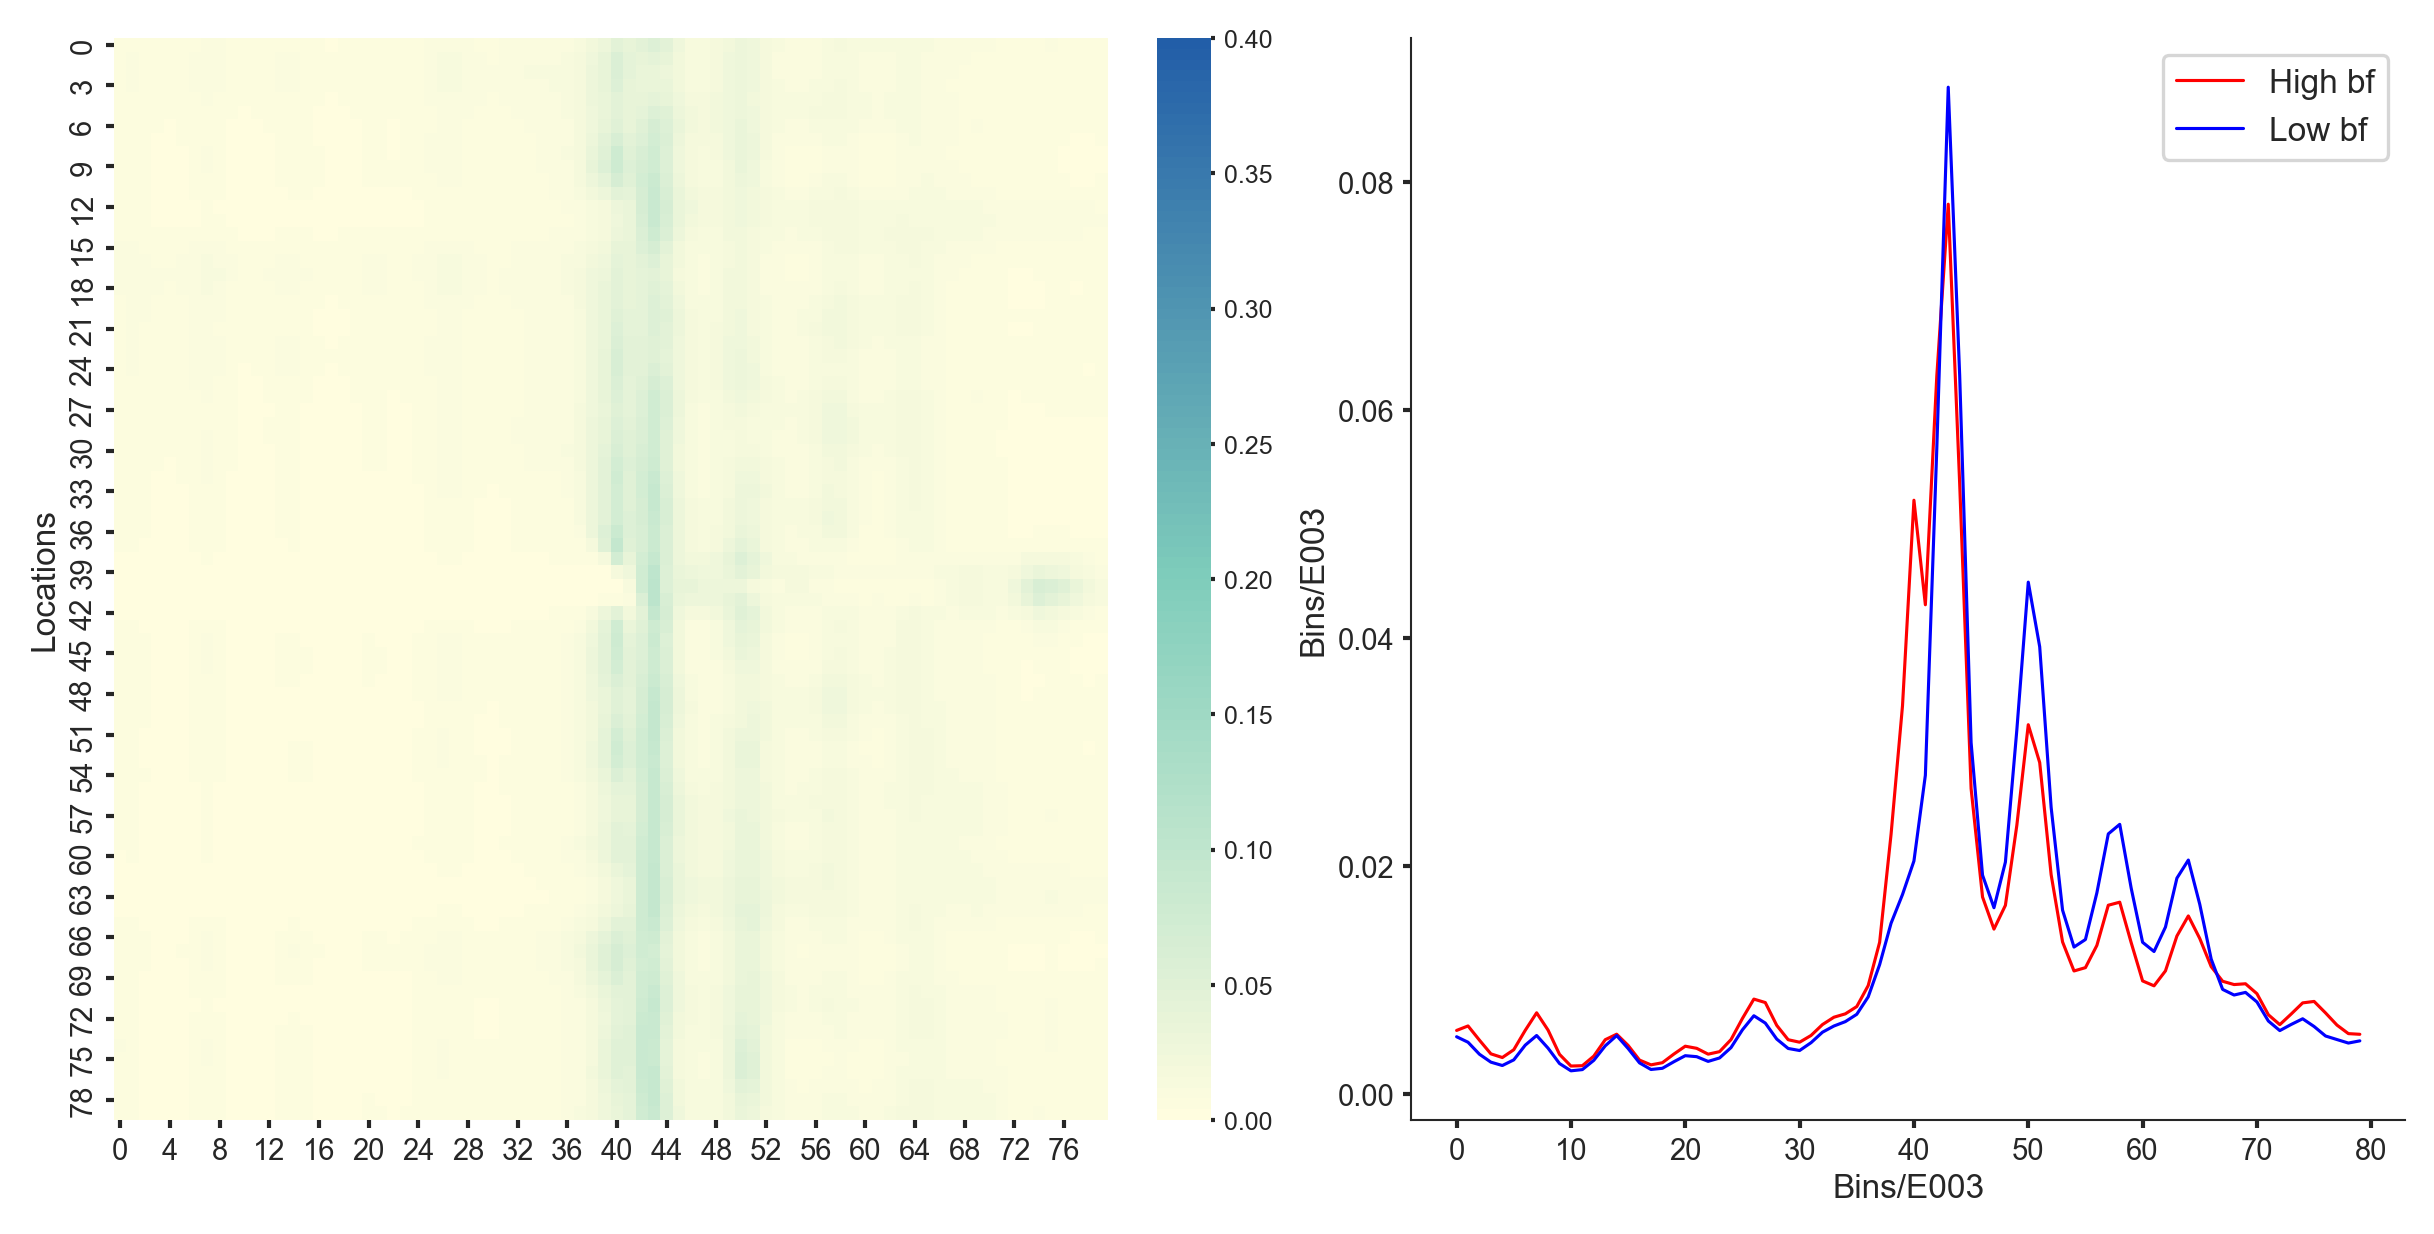

In [9]:

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(8, 4))

plot_heatmap(high_attention_weights,axis=ax[0])
sns.lineplot(high_attention_distribution,label='High bf',ax=ax[1],color='red')
sns.lineplot(low_attention_distribution,label='Low bf',ax=ax[1],color='blue')
plt.xlabel(f"Bins/{eid}")
plt.ylabel(f"Bins/{eid}")

plt.show()

  0%|          | 0/7154 [00:00<?, ?it/s]

100%|██████████| 7150/7150 [01:19<00:00, 90.33it/s]


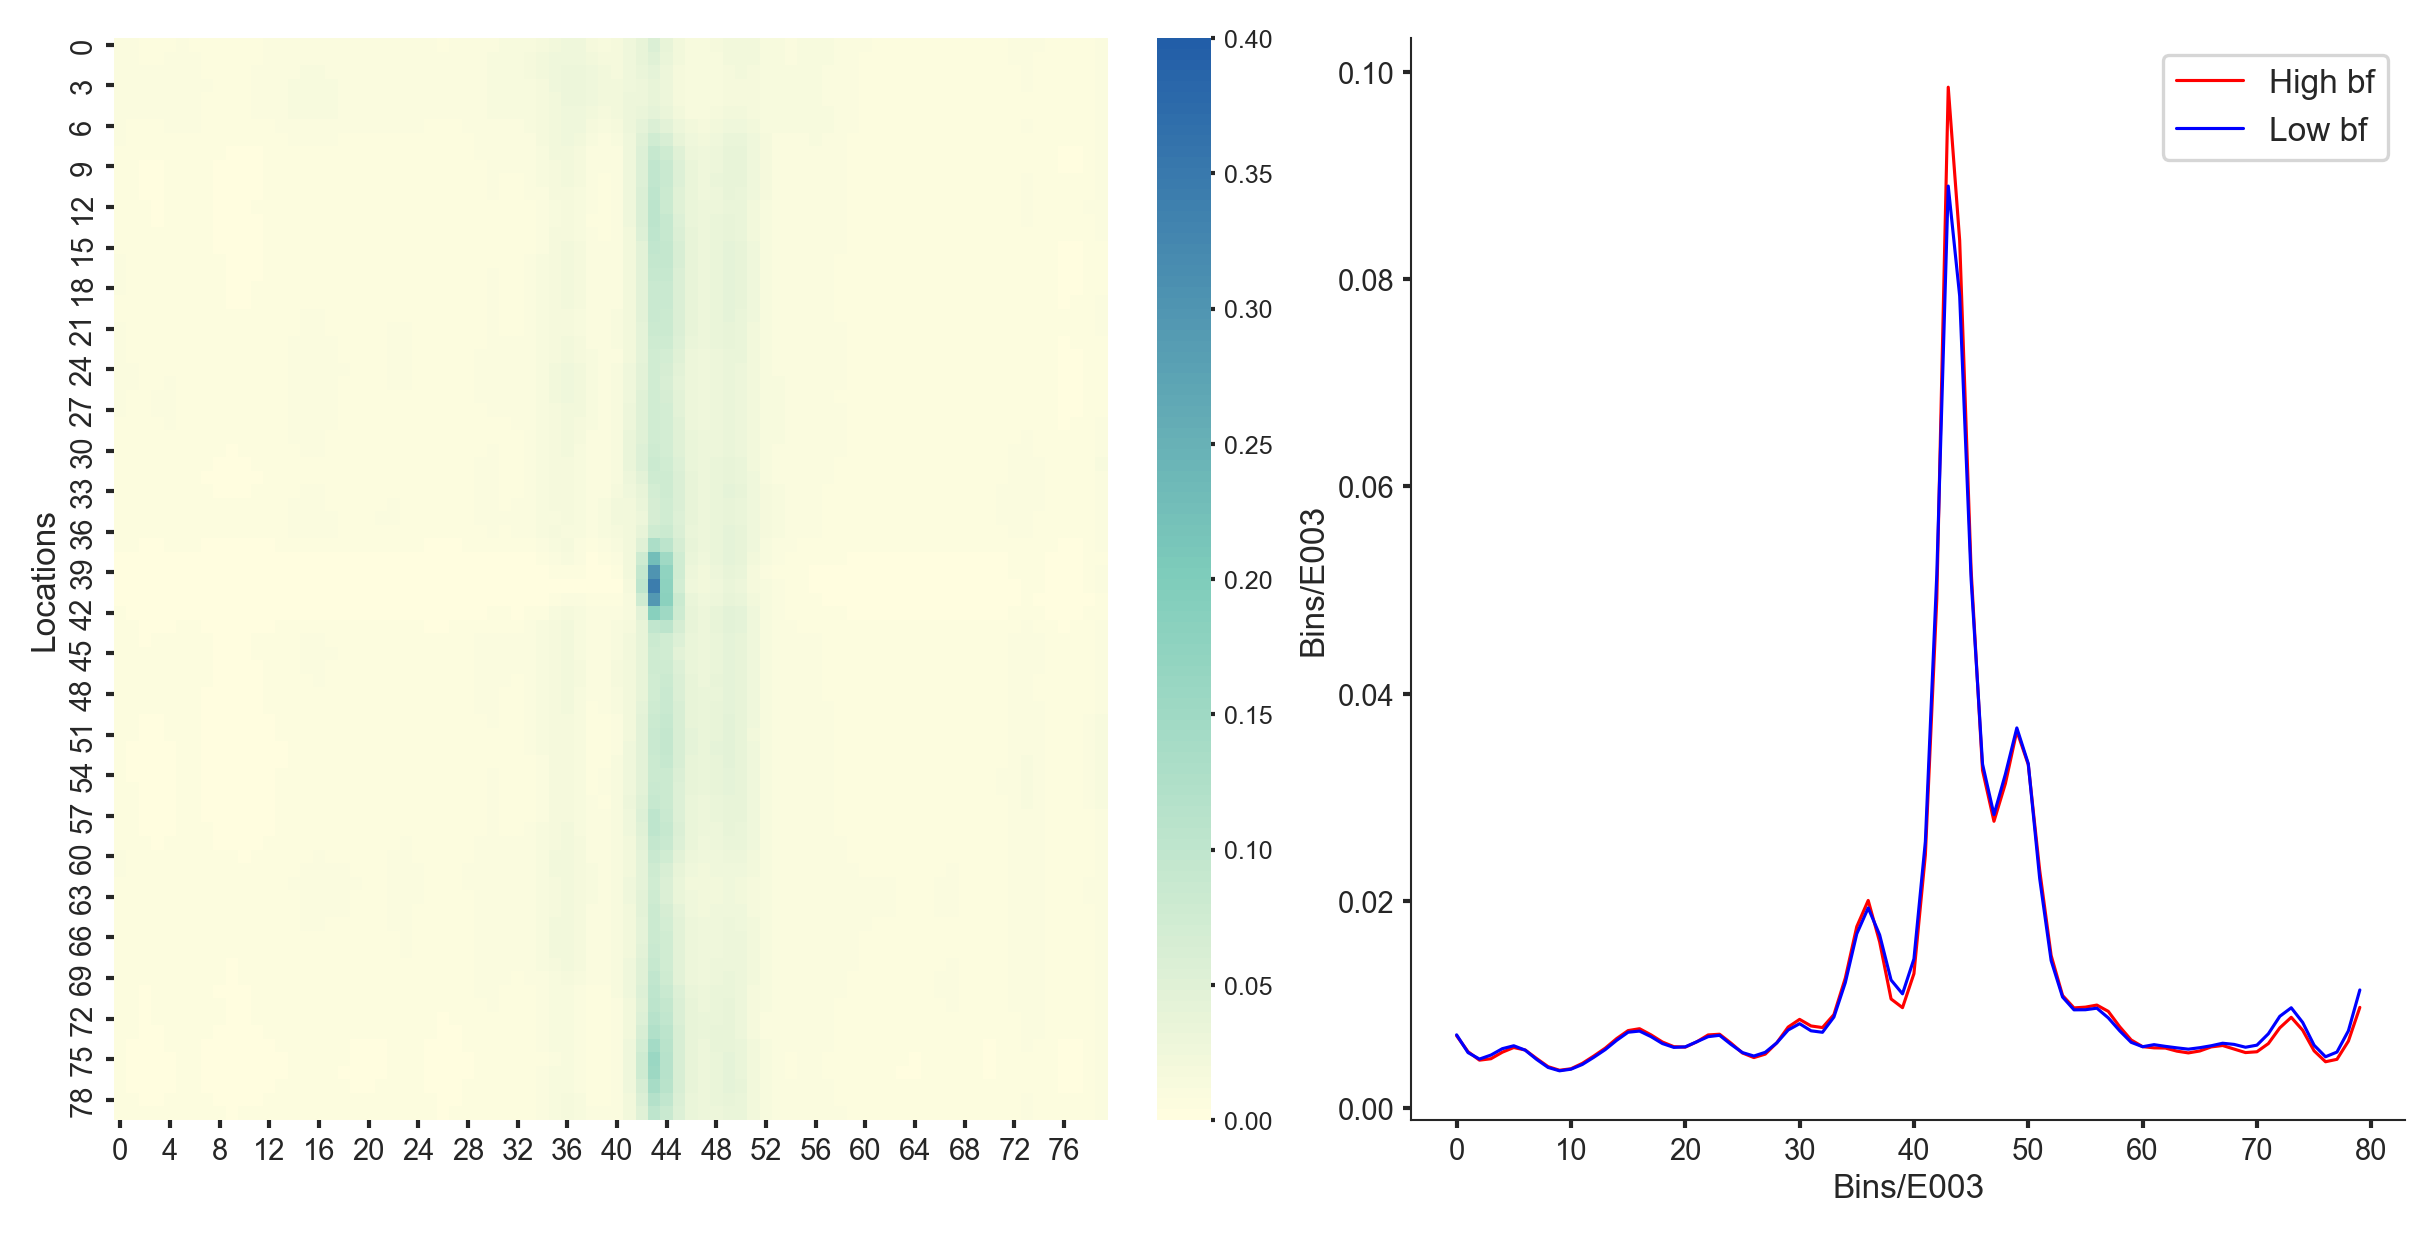

In [10]:
high_gene_ids = data[(data['labels_marks'].isin([LABEL_BIN_MAP['Low bs and high bf'],LABEL_BIN_MAP['High bs and high bf']])) ]

high_attention_weights = 0
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    high_attention_weights += get_attention_weights(gene_id, datasets_without_h3k36me3[fold], models_without_h3k36me3[fold], binsize=binsizes[0],dims=dims)

high_attention_weights = high_attention_weights/len(high_gene_ids)

high_attention_distribution = np.mean(high_attention_weights, axis=0)


low_gene_ids =  data[(data['labels_marks'].isin([LABEL_BIN_MAP['Low bs and low bf'],LABEL_BIN_MAP['High bs and low bf']])) ]

low_attention_weights = 0
for record in tqdm(low_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    low_attention_weights += get_attention_weights(gene_id, datasets_without_h3k36me3[fold], models_without_h3k36me3[fold], binsize=binsizes[0],dims=dims)

low_attention_weights = low_attention_weights/len(high_gene_ids)

low_attention_distribution = np.mean(low_attention_weights, axis=0)



fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(8, 4))

plot_heatmap(high_attention_weights,axis=ax[0])
sns.lineplot(high_attention_distribution,label='High bf',ax=ax[1],color='red')
sns.lineplot(low_attention_distribution,label='Low bf',ax=ax[1],color='blue')

plt.xlabel(f"Bins/{eid}")
plt.ylabel(f"Bins/{eid}")

plt.show()



### ALL datasets(High and Low BS)

  0%|          | 0/7149 [00:00<?, ?it/s]

100%|██████████| 9431/9431 [01:43<00:00, 90.76it/s]


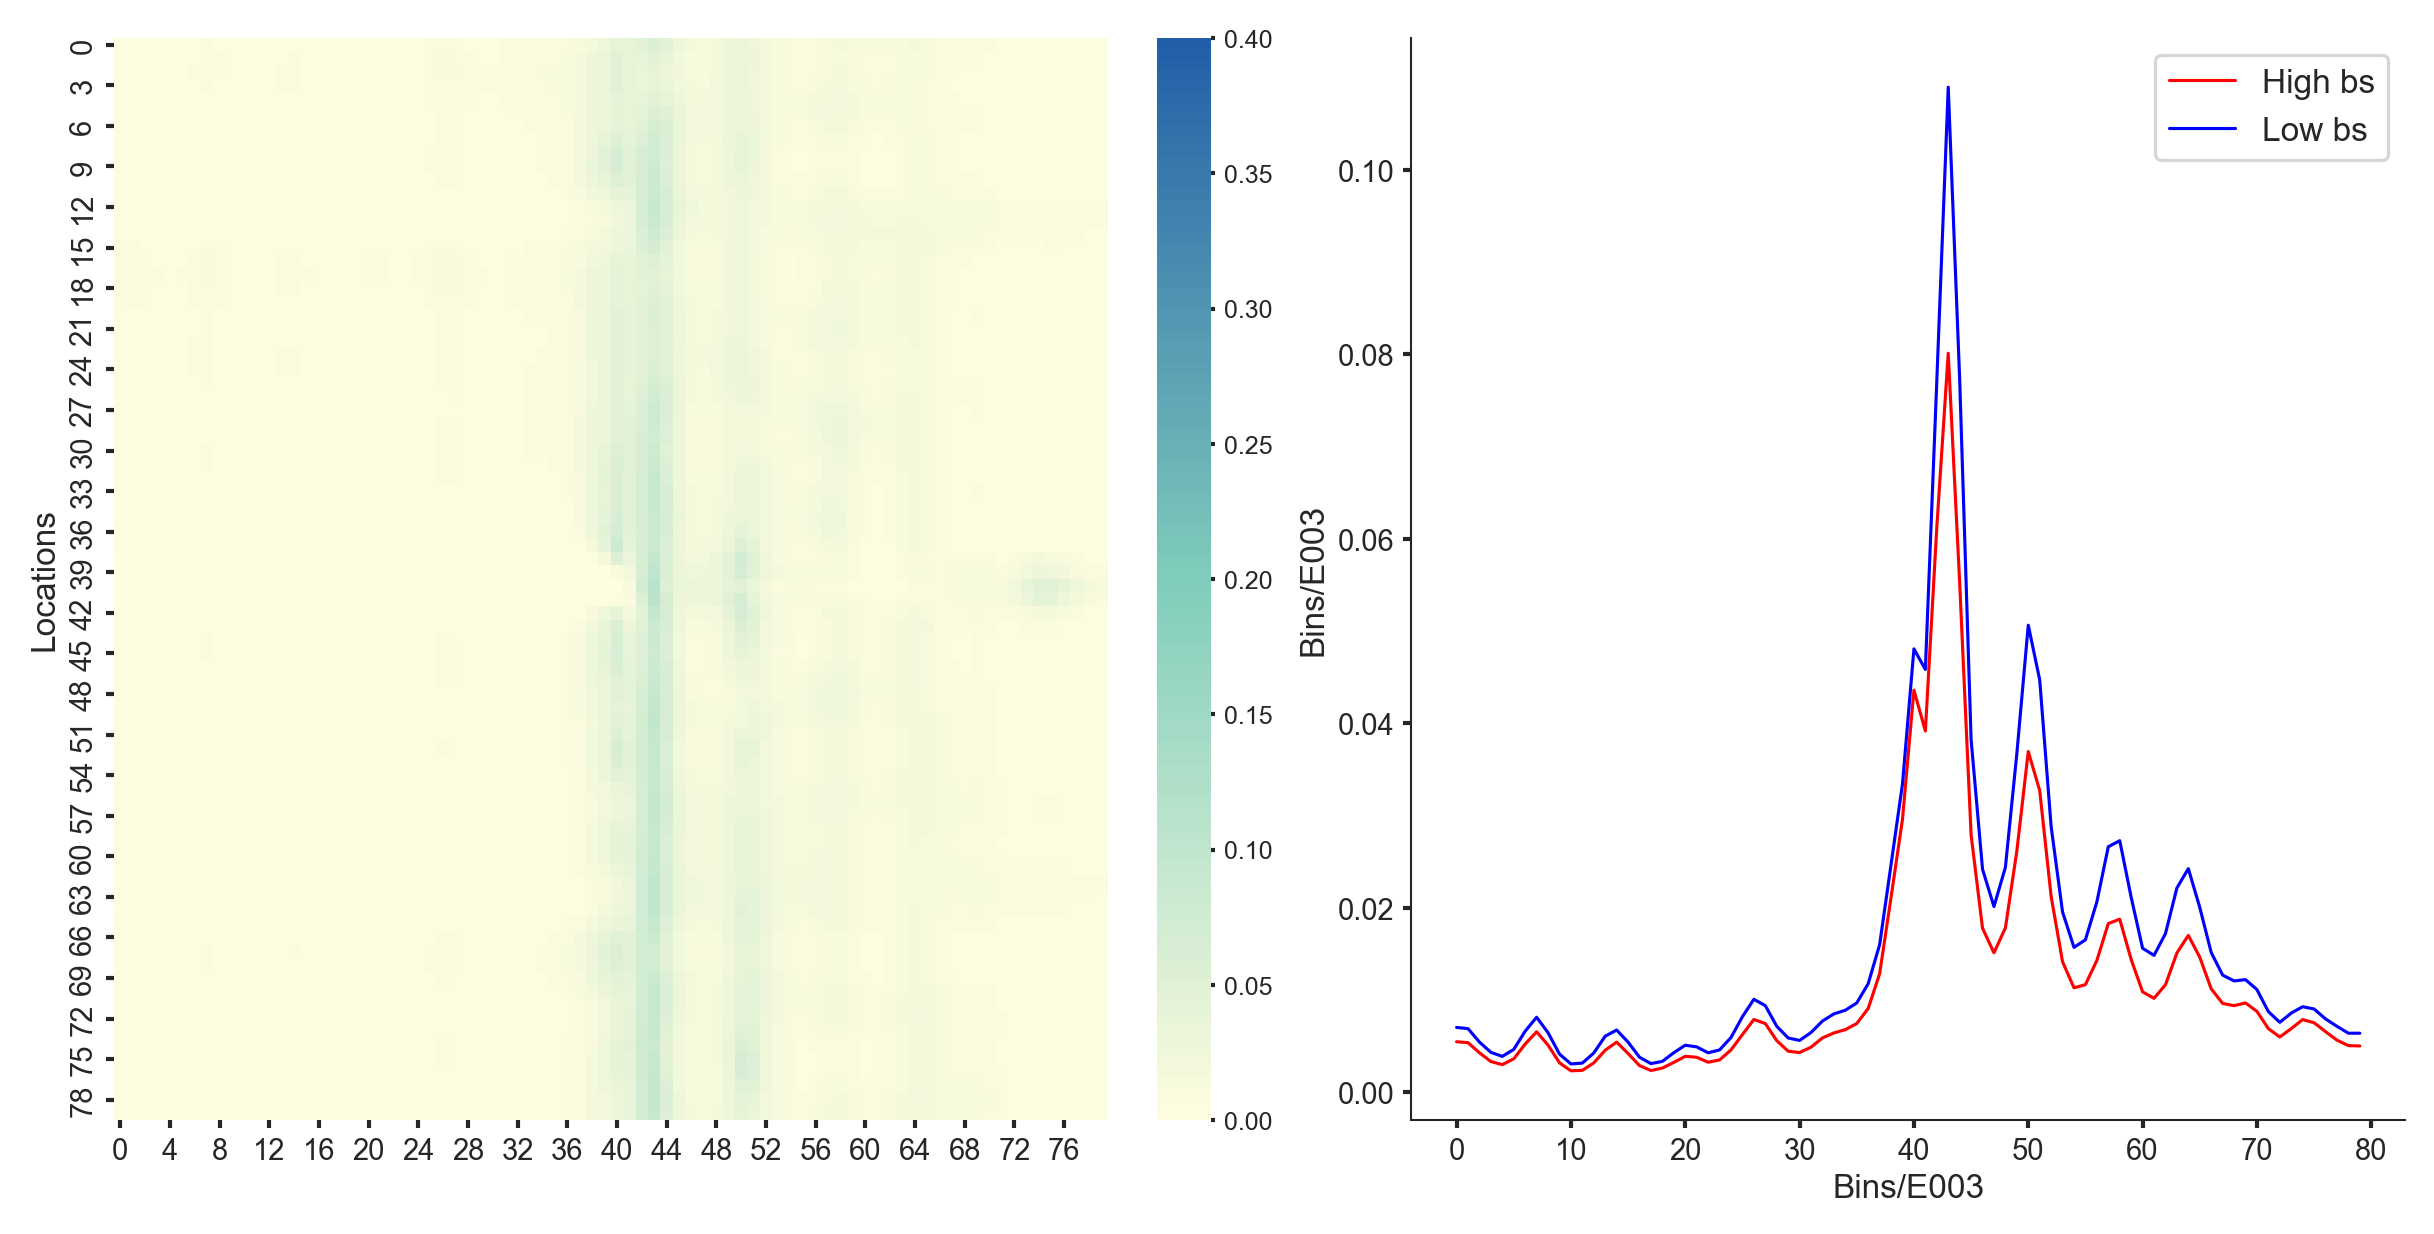

In [11]:
high_gene_ids = data[(data['labels_marks'].isin([LABEL_BIN_MAP['High bs and low bf'],LABEL_BIN_MAP['High bs and high bf']])) ]

high_attention_weights = 0
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    high_attention_weights += get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=dims)

high_attention_weights = high_attention_weights/len(high_gene_ids)

high_attention_distribution = np.mean(high_attention_weights, axis=0)


low_gene_ids =  data[(data['labels_marks'].isin([LABEL_BIN_MAP['Low bs and low bf'],LABEL_BIN_MAP['High bs and high bf']])) ]

low_attention_weights = 0
for record in tqdm(low_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    low_attention_weights += get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=dims)

low_attention_weights = low_attention_weights/len(high_gene_ids)

low_attention_distribution = np.mean(low_attention_weights, axis=0)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(8, 4))

plot_heatmap(high_attention_weights,axis=ax[0])
sns.lineplot(high_attention_distribution,label='High bs',ax=ax[1],color='red')
sns.lineplot(low_attention_distribution,label='Low bs',ax=ax[1],color='blue')
plt.xlabel(f"Bins/{eid}")
plt.ylabel(f"Bins/{eid}")

plt.show()


  0%|          | 0/7149 [00:00<?, ?it/s]

100%|██████████| 7155/7155 [01:18<00:00, 91.05it/s]


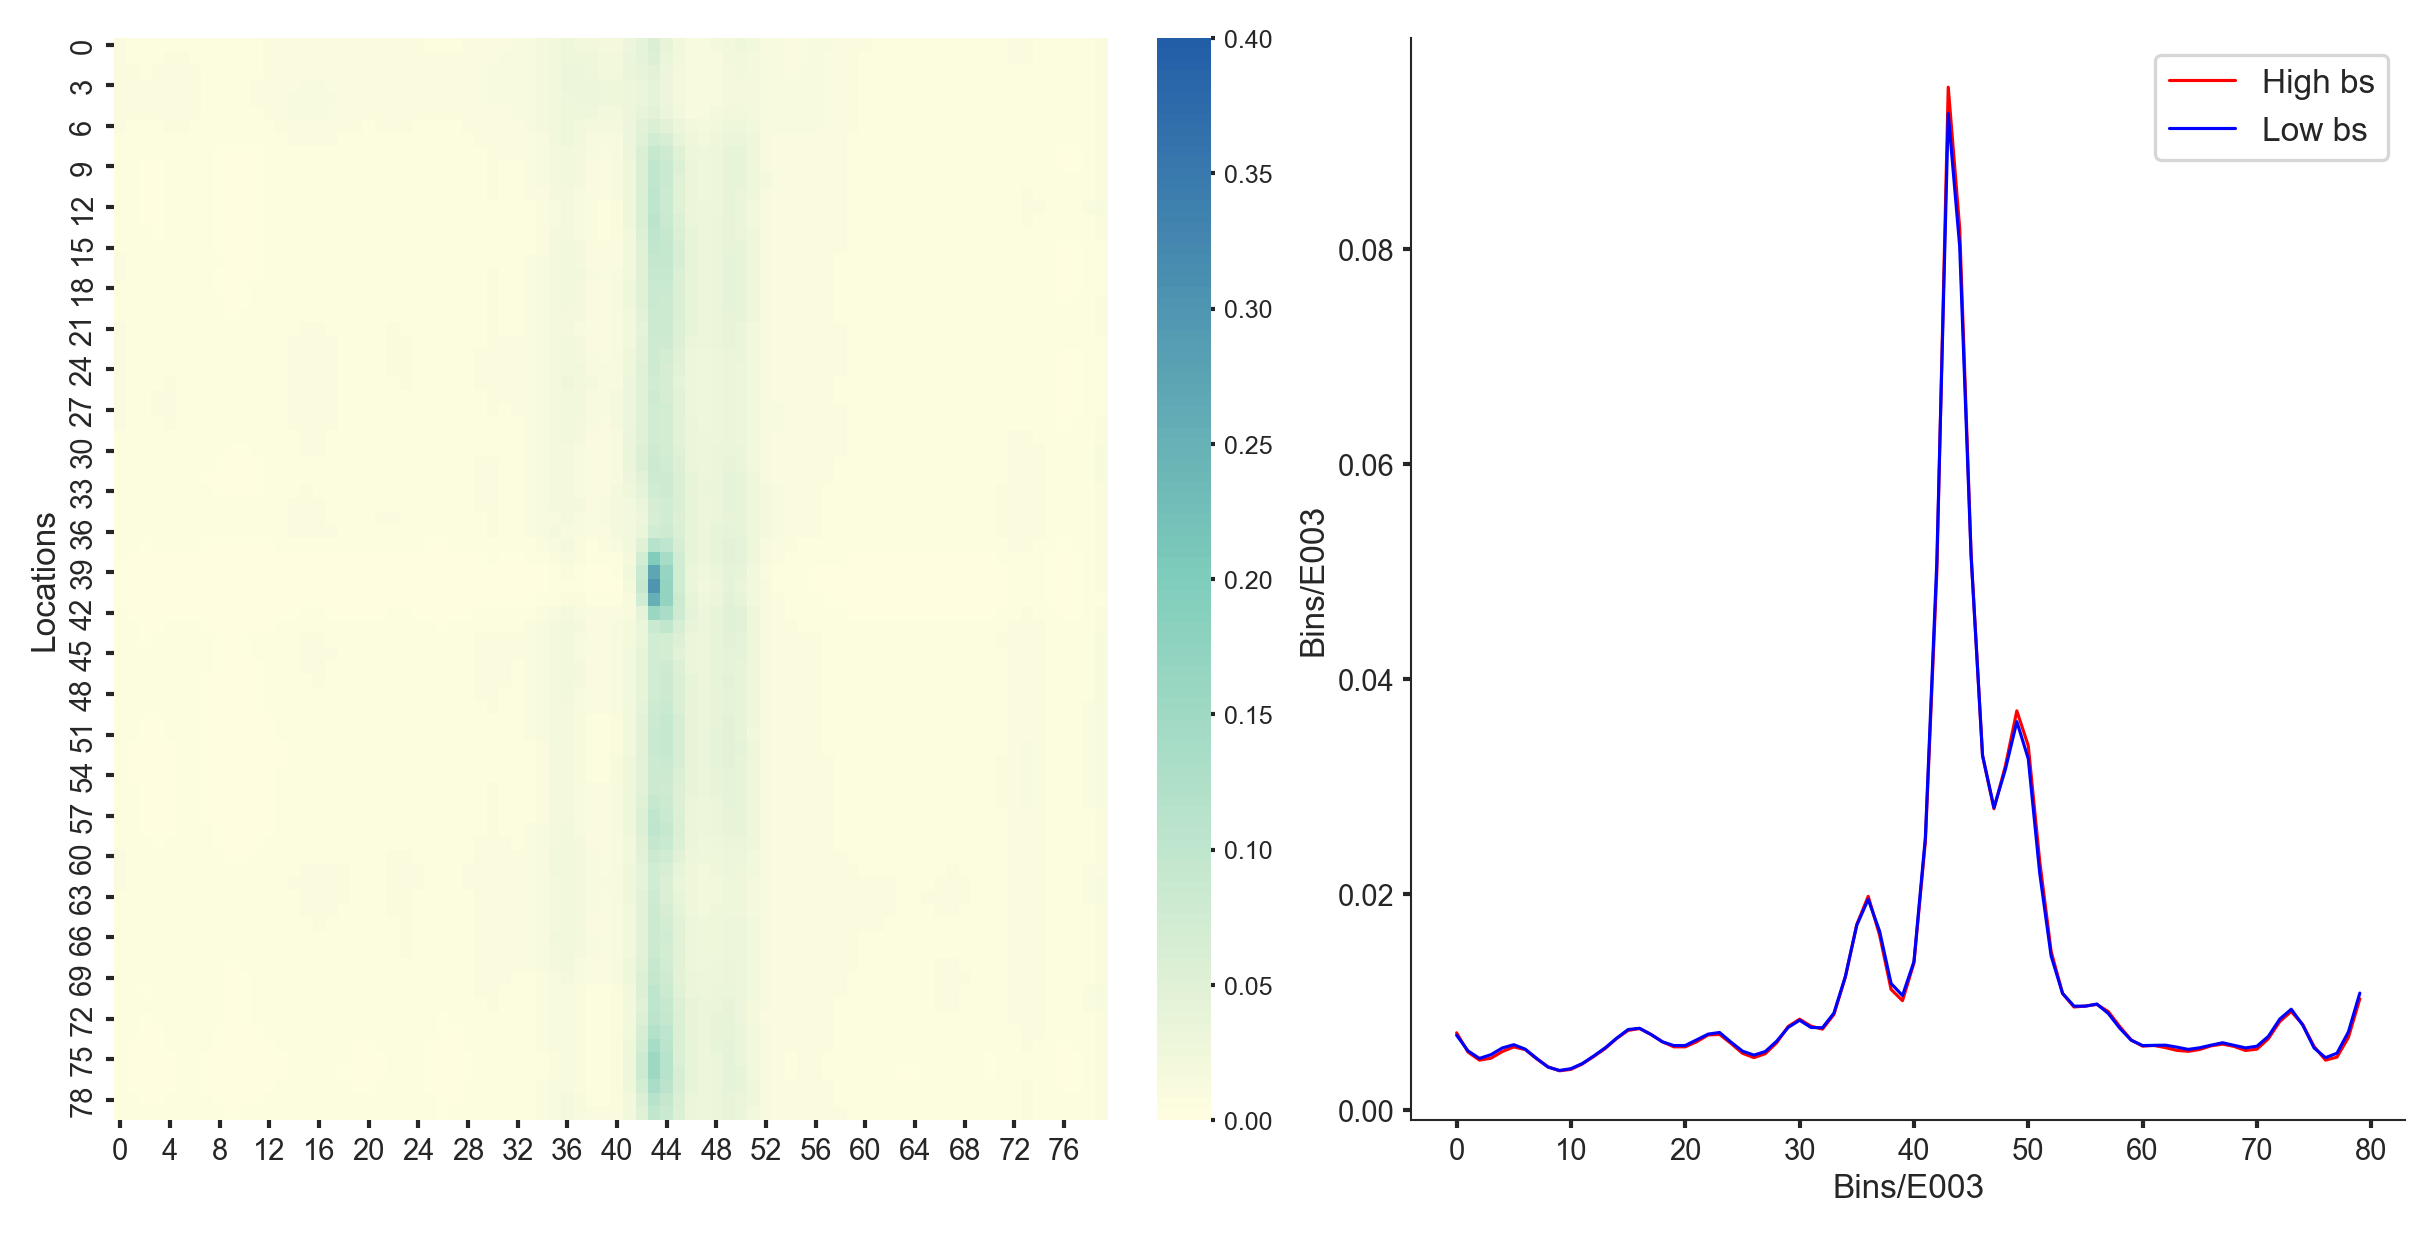

In [12]:
high_gene_ids = data[(data['labels_marks'].isin([LABEL_BIN_MAP['High bs and low bf'],LABEL_BIN_MAP['High bs and high bf']])) ]

high_attention_weights = 0
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    high_attention_weights += get_attention_weights(gene_id, datasets_without_h3k36me3[fold], models_without_h3k36me3[fold], binsize=binsizes[0],dims=dims)

high_attention_weights = high_attention_weights/len(high_gene_ids)

high_attention_distribution = np.mean(high_attention_weights, axis=0)


low_gene_ids =  data[(data['labels_marks'].isin([LABEL_BIN_MAP['Low bs and low bf'],LABEL_BIN_MAP['Low bs and high bf']])) ]

low_attention_weights = 0
for record in tqdm(low_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    low_attention_weights += get_attention_weights(gene_id, datasets_without_h3k36me3[fold], models_without_h3k36me3[fold], binsize=binsizes[0],dims=dims)

low_attention_weights = low_attention_weights/len(high_gene_ids)

low_attention_distribution = np.mean(low_attention_weights, axis=0)



fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(8, 4))

plot_heatmap(high_attention_weights,axis=ax[0])
sns.lineplot(high_attention_distribution,label='High bs',ax=ax[1],color='red')
sns.lineplot(low_attention_distribution,label='Low bs',ax=ax[1],color='blue')

plt.xlabel(f"Bins/{eid}")
plt.ylabel(f"Bins/{eid}")

plt.show()



### ALL datasets

100%|██████████| 14304/14304 [02:42<00:00, 88.17it/s]


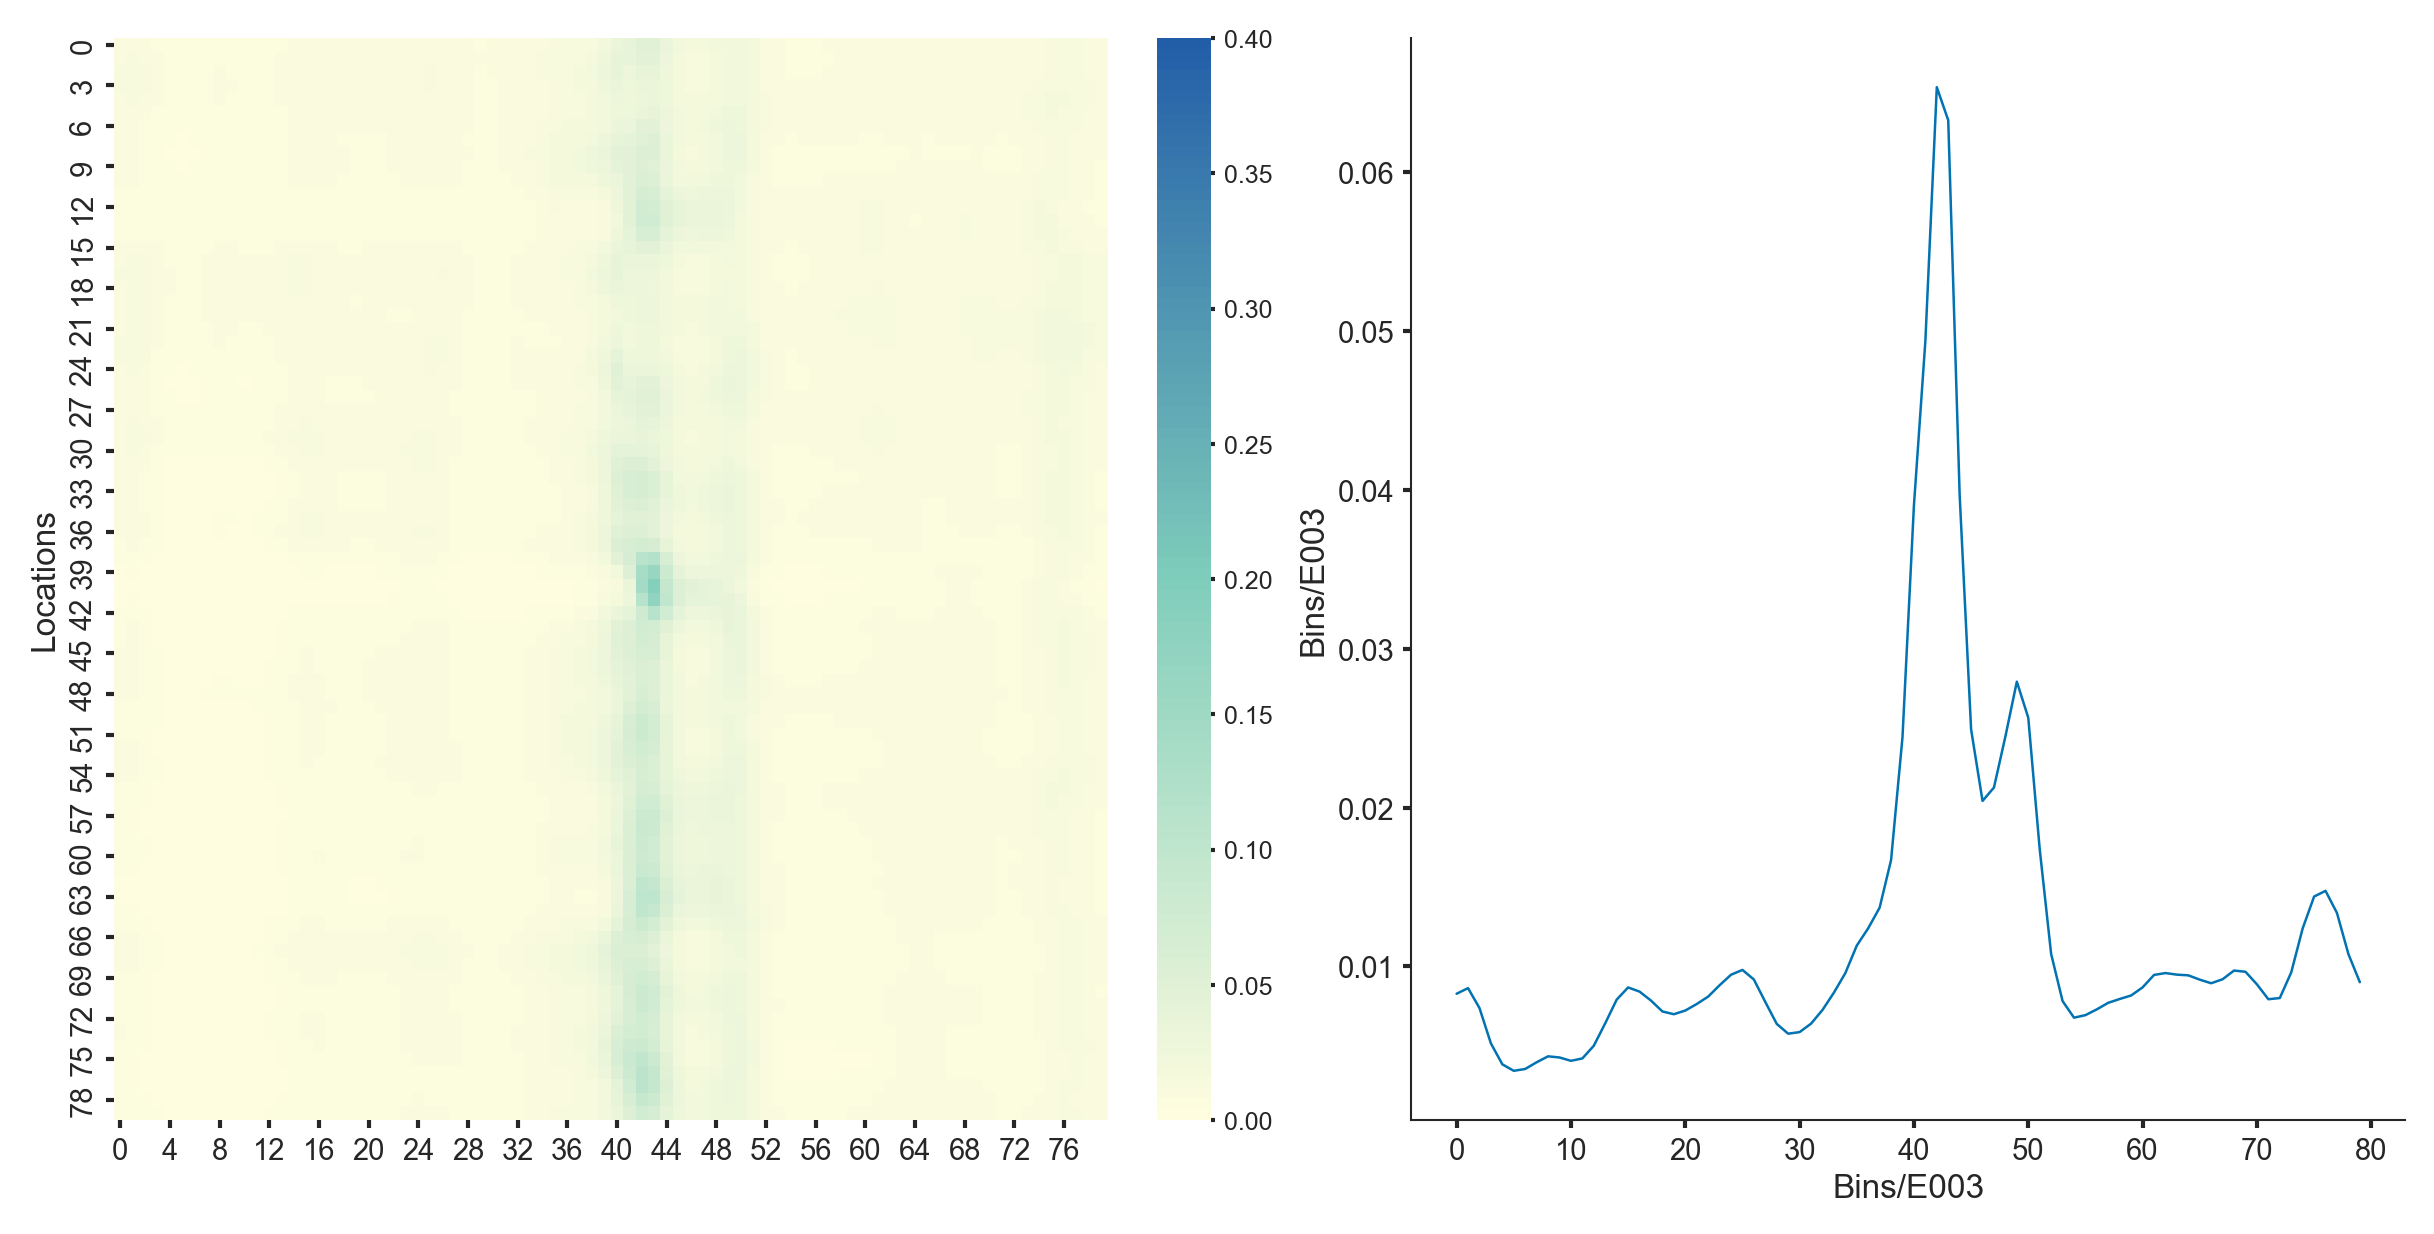

In [10]:
high_gene_ids = data

attention_weights = 0
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    attention_weights += get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=dims)

attention_weights = attention_weights/len(high_gene_ids)

attention_distribution = np.mean(attention_weights, axis=0)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(8, 4))

plot_heatmap(attention_weights,axis=ax[0])
plt.plot(attention_distribution,lw=0.6, label='Feature Importance')

plt.xlabel(f"Bins/{eid}")
plt.ylabel(f"Bins/{eid}")

plt.show()






100%|██████████| 14304/14304 [02:45<00:00, 86.17it/s]


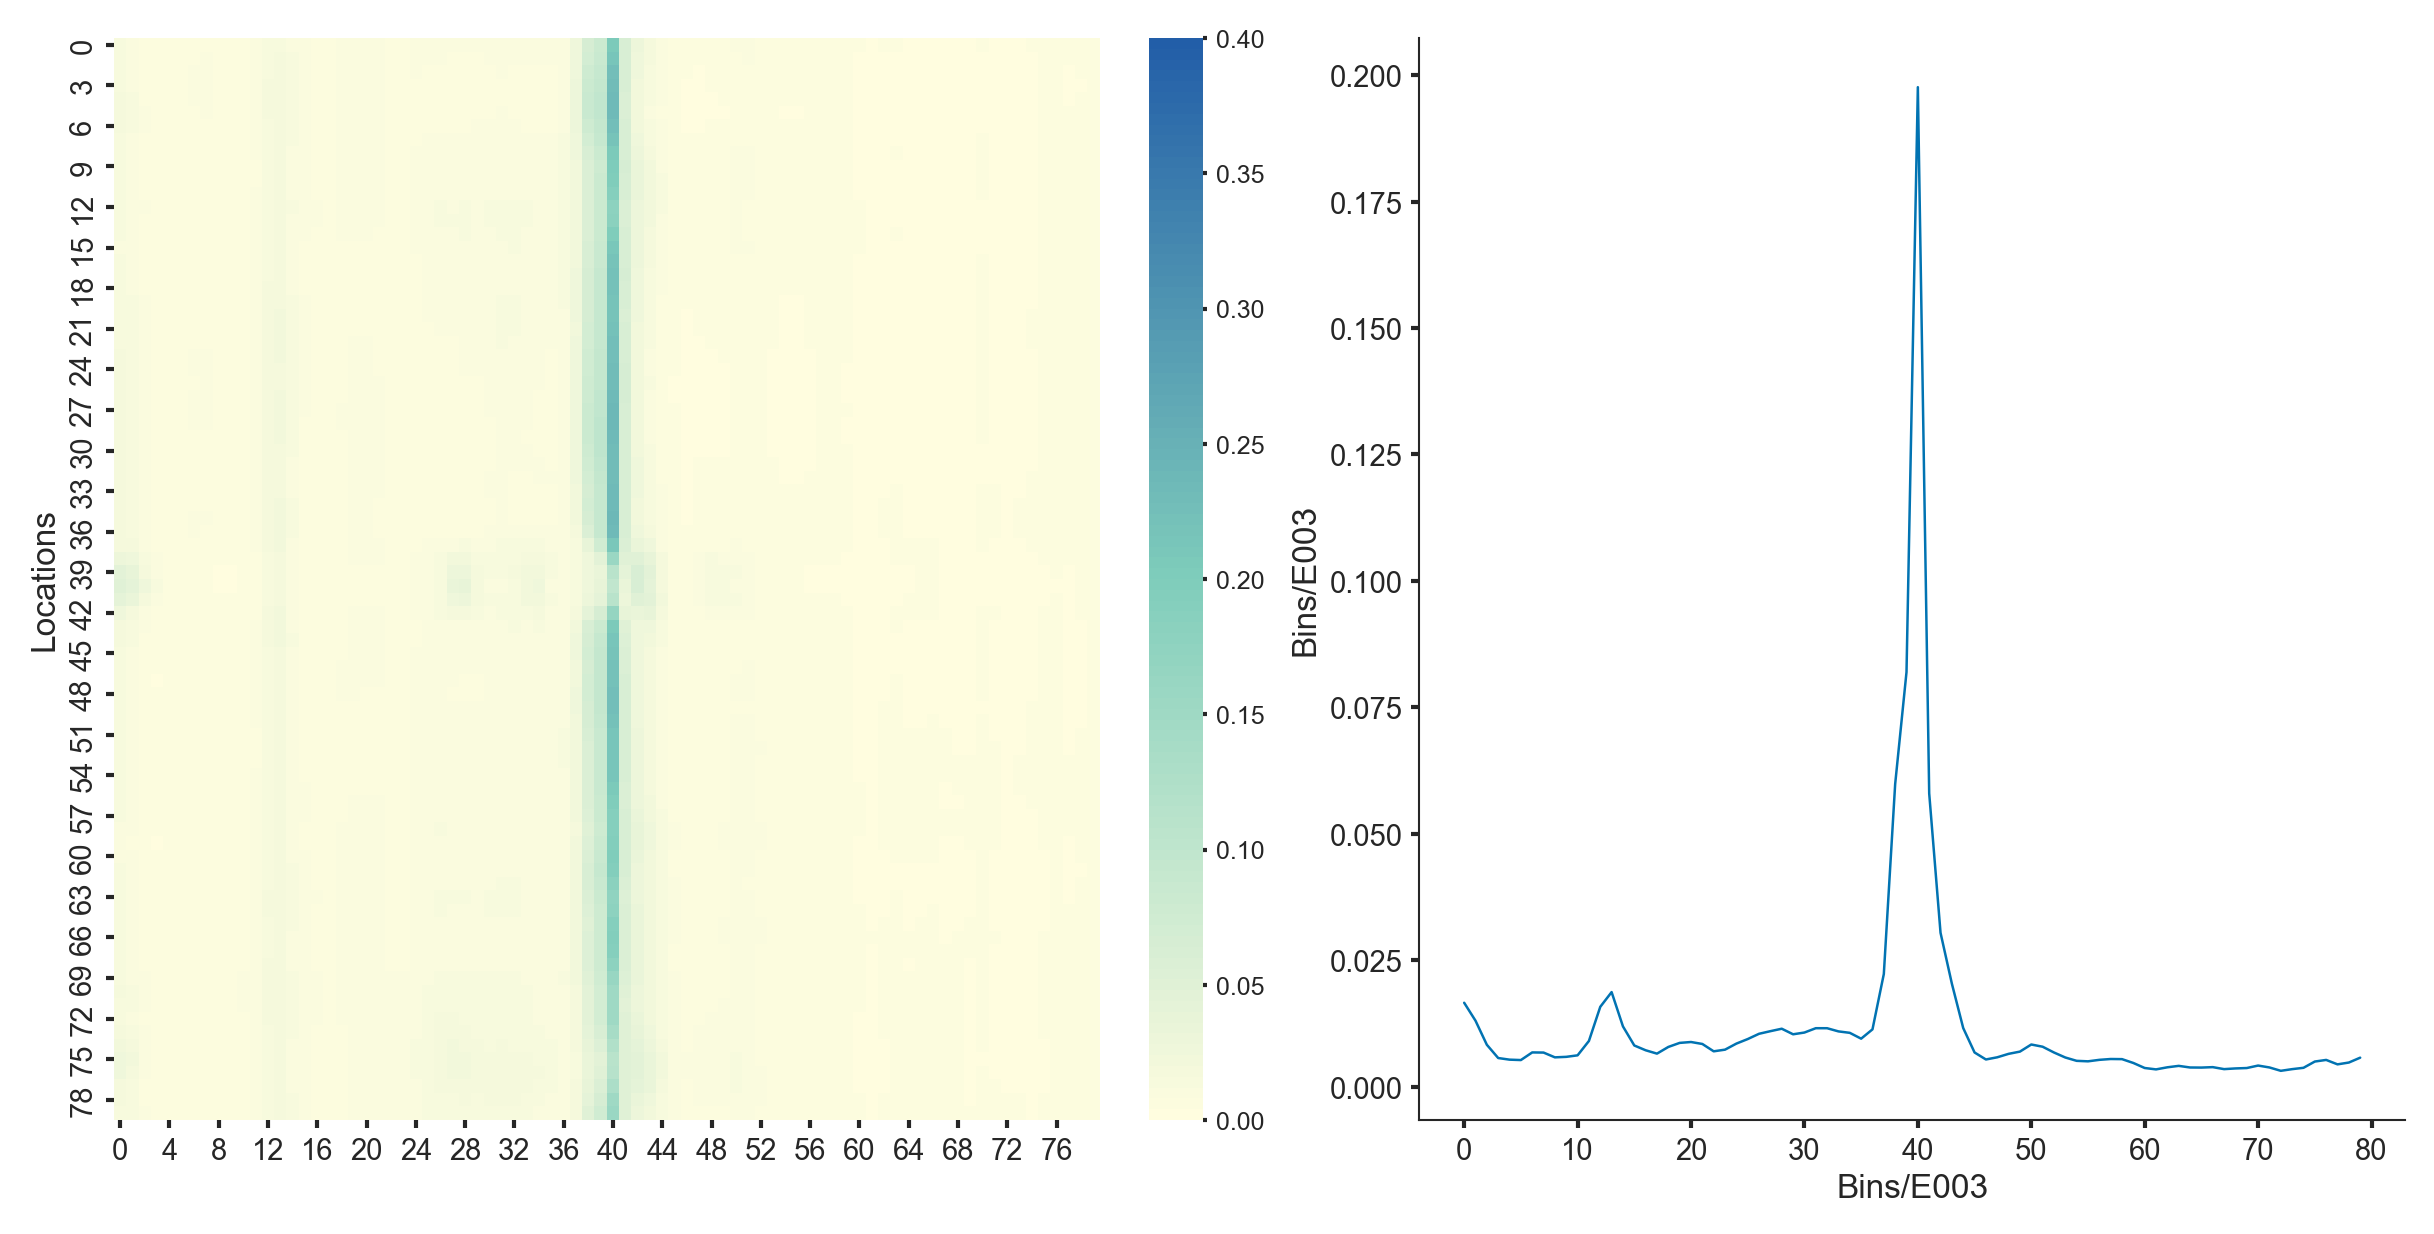

In [11]:
high_gene_ids = data

attention_weights = 0
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    attention_weights += get_attention_weights(gene_id, datasets_without_h3k36me3[fold], models_without_h3k36me3[fold], binsize=binsizes[0],dims=dims)

attention_weights = attention_weights/len(high_gene_ids)

attention_distribution = np.mean(attention_weights, axis=0)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(8, 4))

plot_heatmap(attention_weights,axis=ax[0])
plt.plot(attention_distribution,lw=0.6, label='Feature Importance')

plt.xlabel(f"Bins/{eid}")
plt.ylabel(f"Bins/{eid}")

plt.show()


## Attention Case Analysis

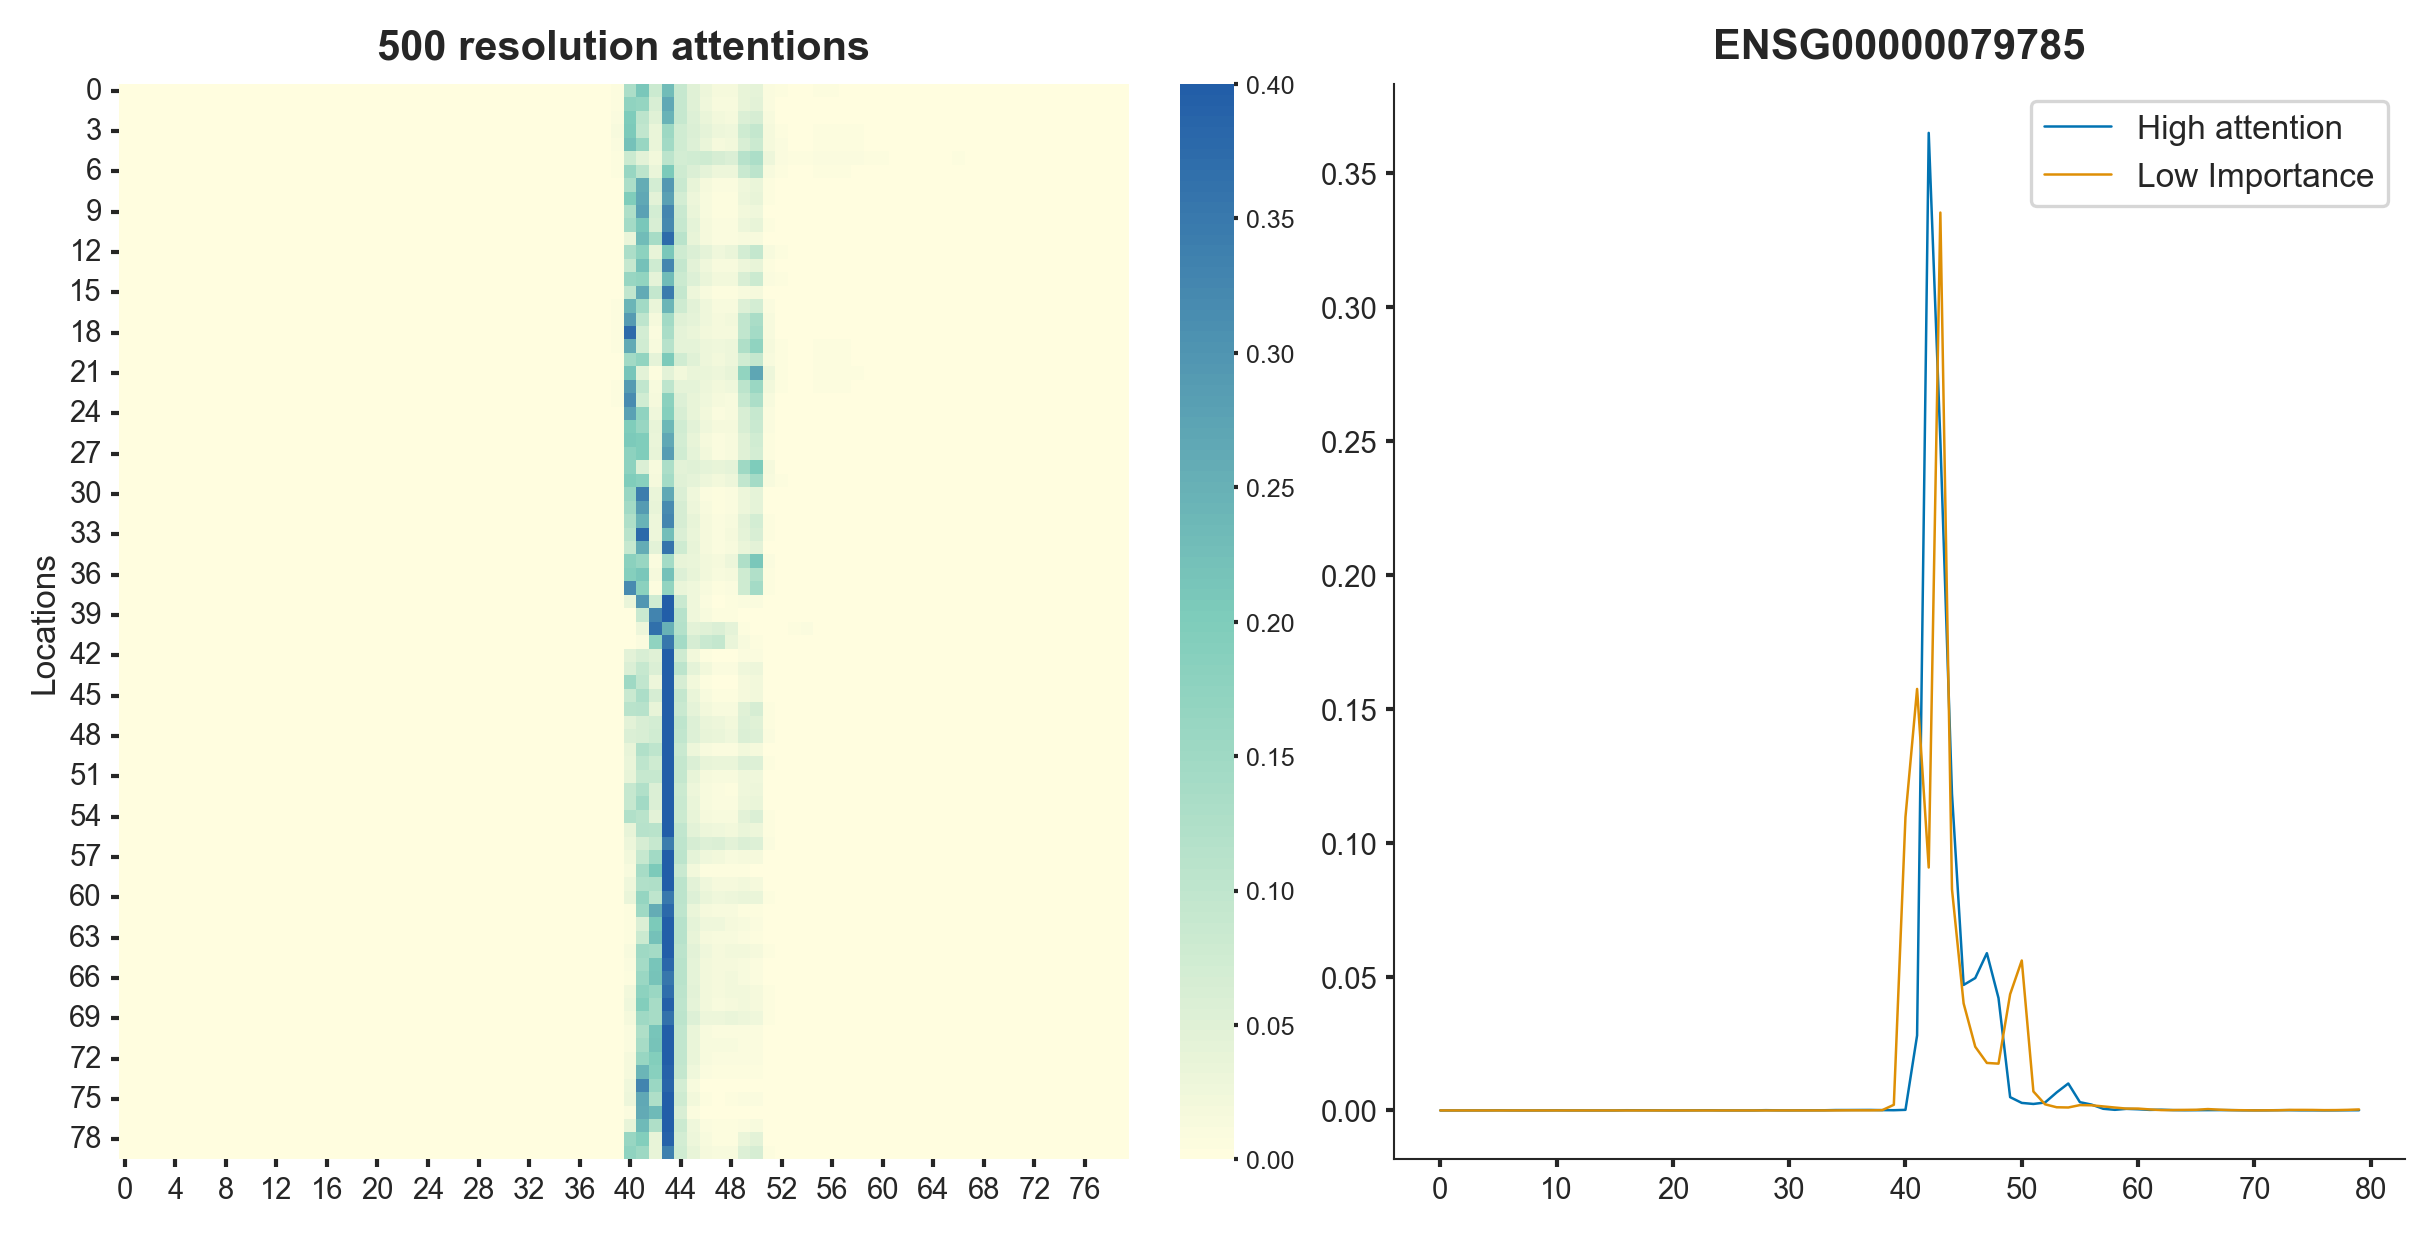

In [16]:


gene_id = 'ENSG00000079785'
fold = 3
attention_weights = get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=0)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(8, 4))

plot_heatmap(attention_weights,axis=ax[0], title="500 resolution attentions")
promoter_attentions = attention_weights[40]
attention_distribution = np.mean(attention_weights, axis=0)

# plot_heatmap(attention_weights_500,axis=ax[1], title="500 resolution | Head 2")
plt.plot(promoter_attentions, lw=0.6,label="High attention")
plt.plot(attention_distribution,lw=0.6, label='Low Importance')
plt.title(f'{gene_id}')
plt.legend(loc='upper right')
plt.show()



## pCRE analysis

In [1]:
from src.data.genomics import get_cres_infos, get_gene_infos
cres_infos = get_cres_infos('extra/datasets/genomic/GRCh19-cCREs.bed')
gene_infos = get_gene_infos('extra/datasets/genomic/genes.bed')

-2025-10-05 12:26:36,220-INFO Start loading cres infos
100%|██████████| 1061709/1061709 [00:11<00:00, 88921.48it/s] 
-2025-10-05 12:26:48,672-INFO Start loading gene infos
100%|██████████| 18955/18955 [00:00<00:00, 215500.34it/s]


In [8]:
counts = {}
with open('extra/datasets/benchmark/Promoterformer/attention2cres.txt','w') as w:
    for record in tqdm(data.to_records()):
        gene_id = record['gene_id']
        gene_info = gene_infos[gene_id]
        chrom = gene_info.chrom
        center = gene_info.transcript_start_site.location
        strand = gene_info.strand

        fold = record['fold']
        weights = get_attention_weights(gene_id,datasets[fold],models[fold])
        promoter_attentions = weights[40]
        genomic_regions = extract_attention_regions(promoter_attentions,chrom=chrom,center=center,strand=strand, threshold=0.05)
        count = []
        regions = [gene_id]
        for genomic_region in genomic_regions:
            cres_info_ids = [genomic_region]
            for cres_info in cres_infos.values():
                if cres_info.is_overlap(genomic_region):
                    cres_info_ids.append(cres_info.id)
            regions.append('|'.join(cres_info_ids))

        line = ','.join(regions)
        w.write(line + '\n')



  1%|          | 152/15420 [11:49<19:47:53,  4.67s/it]


KeyboardInterrupt: 

In [11]:
from intervaltree import Interval, IntervalTree
from src.data.genomics import get_cres_infos, get_gene_infos

# === Step 1. 构建快速查询索引 ===
cres_infos = get_cres_infos('extra/datasets/genomic/GRCh19-cCREs.bed')
gene_infos = get_gene_infos('extra/datasets/genomic/genes.bed')

# 按染色体构建 IntervalTree 索引
cres_trees = {}
for cres in cres_infos.values():
    if cres.region.chrom not in cres_trees:
        cres_trees[cres.region.chrom] = IntervalTree()
    cres_trees[cres.region.chrom].addi(cres.region.start, cres.region.end, cres)

# === Step 2. 扫描所有基因 Attention 区域 ===
out_path = 'extra/datasets/benchmark/Promoterformer/attention2cres_optimized.txt'
records = []

for record in tqdm(data.to_records(), desc="Mapping attention to cCREs"):
    gene_id = record['gene_id']
    gene_info = gene_infos[gene_id]
    chrom = gene_info.chrom
    strand = gene_info.strand
    center = gene_info.transcript_start_site.location
    fold = record['fold']

    weights = get_attention_weights(gene_id, datasets[fold], models[fold])
    promoter_att = weights[40]  # 提取 promoter attention track
    high_att_regions = extract_attention_regions(promoter_att, chrom=chrom, center=center, strand=strand, threshold=0.05)

    overlaps = []
    for region in high_att_regions:
        chrom, start_end = region.split(':')
        start, end = map(int, start_end.split('-'))
        if chrom not in cres_trees:
            continue
        hits = cres_trees[chrom].overlap(start, end)
        for h in hits:
            cres = h.data
            overlaps.append({
                'gene_id': gene_id,
                'chrom': chrom,
                'region_start': start,
                'region_end': end,
                'cres_id': cres.id,
                'cres_type': cres.type,  # e.g., pELS, dELS, CTCF-bound, etc.
                'overlap_start': max(start, cres.region.start),
                'overlap_end': min(end, cres.region.end),
                'overlap_length': min(end, cres.region.end) - max(start, cres.region.start)
            })

    # 若无重叠，也记录空行
    if not overlaps:
        overlaps.append({'gene_id': gene_id, 'chrom': chrom, 'region_start': None, 'cres_id': None, 'cres_type': None})

    records.extend(overlaps)

# === Step 3. 保存结果 ===
df_out = pd.DataFrame(records)
df_out.to_csv(out_path, index=False)
print(f"[Saved] Overlap table: {out_path}")

-2025-10-05 13:19:37,578-INFO Start loading cres infos
100%|██████████| 1061709/1061709 [00:14<00:00, 74531.68it/s] 
-2025-10-05 13:19:52,269-INFO Start loading gene infos
Mapping attention to cCREs:   0%|          | 1/15420 [00:00<45:13,  5.68it/s]


TypeError: unsupported operand type(s) for -: 'int' and 'GenomicSite'

In [ ]:
with open('extra/datasets/benchmark/Promoterformer/attention2cres.txt','r') as f:
    attention2cres = {}
    for line in f.readlines():
        line = line.strip().split(',')
        gene_id = line[0]
        counts = {}
        for items in line[1:]:
            items = items.split('|')
            region = items[0]
            cres_ids = items[1:]
            counts[region] = cres_ids
        attention2cres[gene_id] = counts

attention2cres


cres_nums = []
for record in data.to_records():
    gene_id = record['gene_id']
    counts = attention2cres[gene_id]
    cres = []
    for k, v in counts.items():
        for cres_id in v:
            cres_type = cres_infos[cres_id].type
            if 'dELS' in cres_type or 'pELS' in cres_type:
                cres.append(cres_id)

    cres_nums.append(len(cres))

data['cres_nums'] = cres_nums



ValueError: Length of values (0) does not match length of index (3815)

In [ ]:
counts

{'chr19:3975461-3977461': ['EH38E3284264', 'EH38E3284265', 'EH38E1933733'],
 'chr19:3981961-3982461': ['EH38E1933746', 'EH38E1933747'],
 'chr19:3982961-3984461': ['EH38E1933749',
  'EH38E1933750',
  'EH38E3284272',
  'EH38E1933752']}

In [ ]:
data

,gene_id,bf_pred,bf_label,bf_score,bs_pred,bs_label,bs_score,mean,pred_marks,labels_marks,active,supression,chrom,start,strand,cres_nums
2534,ENSG00000167658,1,1,0.985620,1,1,0.982587,3.328098,High bs and high bf,High bs and high bf,0.0,1.0,chr19,3985461,-,9
2805,ENSG00000136450,1,1,0.984425,1,1,0.982347,1.057821,High bs and high bf,High bs and high bf,0.0,1.0,chr17,56084607,-,3
1163,ENSG00000165119,1,1,0.984356,1,1,0.965689,1.981025,High bs and high bf,High bs and high bf,1.0,1.0,chr9,86595186,-,3
786,ENSG00000010244,1,1,0.982939,1,1,0.964687,1.151698,High bs and high bf,High bs and high bf,0.0,0.0,chr17,30677155,+,2
2089,ENSG00000173812,1,1,0.981166,1,1,0.961481,3.587217,High bs and high bf,High bs and high bf,0.0,0.0,chr17,39845135,+,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2451,ENSG00000175809,0,0,0.000400,0,0,0.015201,0.000000,Low bs and low bf,Low bs and low bf,0.0,0.0,chrX,22291028,+,0
1951,ENSG00000171054,0,0,0.000398,0,0,0.019081,0.000000,Low bs and low bf,Low bs and low bf,0.0,0.0,chrX,130678046,+,0
3770,ENSG00000181733,0,0,0.000386,0,0,0.011229,0.000000,Low bs and low bf,Low bs and low bf,0.0,0.0,chr19,8841314,+,0
2487,ENSG00000165202,0,0,0.000344,0,0,0.018477,0.000000,Low bs and low bf,Low bs and low bf,0.0,0.0,chr9,125377015,+,0


<Axes: xlabel='mean', ylabel='cres_nums'>

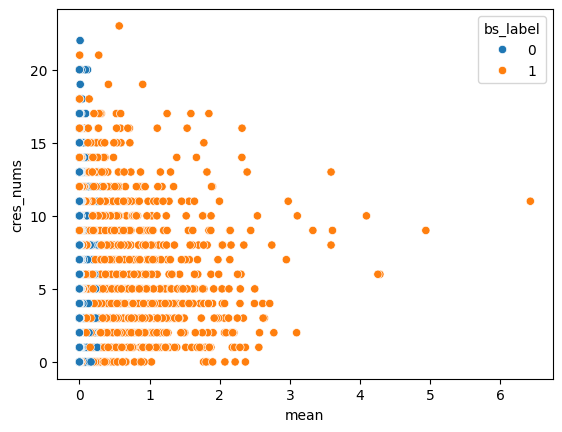

In [ ]:
sns.scatterplot(data=data, x = 'mean' ,y='cres_nums',hue='bs_label')

In [ ]:
counts = {}
df = data[data['labels_marks'] == 'High bs and high bf']
for row in tqdm(df.to_records()):
    gene_id = row['gene_id']
    counts = attention2cres[gene_id]
    

In [ ]:
counts = {}
df = data[data['labels_marks'] == 'High bs and high bf']
for row in tqdm(df.to_records()):
    genomic_regions = row['attention_regions']
    for cres_info in cres_infos.values():
        for genomic_region in genomic_regions:
            if cres_info.is_overlap(genomic_region):
                cres_type = cres_info.type
                if cres_type not in counts:
                    counts[cres_type] = 1
                else:
                    counts[cres_type] += 1


counts

 93%|█████████▎| 1235/1323 [4:24:50<04:48,  3.28s/it]   

In [ ]:
counts_1 = {}
df = data[data['labels_marks'] == 'Low bs and high bf']
for row in tqdm(df.to_records()):
    genomic_regions = row['attention_regions']
    for cres_info in cres_infos.values():
        for genomic_region in genomic_regions:
            if cres_info.is_overlap(genomic_region):
                cres_type = cres_info.type
                if cres_type not in counts_1:
                    counts_1[cres_type] = 1
                else:
                    counts_1[cres_type] += 1


counts_1

100%|██████████| 10/10 [00:32<00:00,  3.28s/it]


{'PLS,CTCF-bound': 1,
 'pELS,CTCF-bound': 21,
 'pELS': 13,
 'dELS': 2,
 'dELS,CTCF-bound': 4,
 'DNase-H3K4me3,CTCF-bound': 1}

In [ ]:
counts_2 = {}
df = data[data['labels_marks'] == 'High bs and low bf']
for row in tqdm(df.to_records()):
    genomic_regions = row['attention_regions']
    for cres_info in cres_infos.values():
        for genomic_region in genomic_regions:
            if cres_info.is_overlap(genomic_region):
                cres_type = cres_info.type
                if cres_type not in counts_2:
                    counts_2[cres_type] = 1
                else:
                    counts_2[cres_type] += 1
counts_2

100%|██████████| 10/10 [00:32<00:00,  3.25s/it]


{'dELS': 9,
 'pELS': 18,
 'pELS,CTCF-bound': 17,
 'PLS,CTCF-bound': 3,
 'dELS,CTCF-bound': 4}

In [ ]:
counts_3 = {}
df = data[data['labels_marks'] == 'Low bs and low bf']
for row in tqdm(df.to_records()):
    genomic_regions = row['attention_regions']
    for cres_info in cres_infos.values():
        for genomic_region in genomic_regions:
            if cres_info.is_overlap(genomic_region):
                cres_type = cres_info.type
                if cres_type not in counts_3:
                    counts_3[cres_type] = 1
                else:
                    counts_3[cres_type] += 1


counts_3

100%|██████████| 10/10 [00:33<00:00,  3.31s/it]


{'pELS,CTCF-bound': 16,
 'CTCF-only,CTCF-bound': 1,
 'pELS': 16,
 'PLS,CTCF-bound': 3,
 'PLS': 2,
 'dELS': 4,
 'dELS,CTCF-bound': 1}

In [ ]:
gene_info = gene_infos[gene_id]
chrom = gene_info.chrom
center = gene_info.transcript_start_site.location
strand = gene_info.strand
genomic_regions = extract_attention_regions(promoter_attentions,chrom=chrom,center=center,strand=strand, threshold=0.05)
genomic_regions

counts = {}


for cres_info in tqdm(cres_infos.values()):
    for genomic_region in genomic_regions:
        if cres_info.is_overlap(genomic_region):
            if genomic_region not in counts:
                counts[genomic_region] = [cres_info]
            else:
                counts[genomic_region].append(cres_info)
   
counts



100%|██████████| 1061709/1061709 [00:03<00:00, 294668.93it/s]


{'chr17:73771360-73772860': [EH38E1886278 dELS,CTCF-bound,
  EH38E3243844 dELS,CTCF-bound,
  EH38E3243845 dELS,
  EH38E1886281 dELS,CTCF-bound],
 'chr17:73773360-73775360': [EH38E1886283 pELS,
  EH38E3243846 pELS,
  EH38E3243847 pELS,CTCF-bound,
  EH38E3243848 PLS,CTCF-bound,
  EH38E3243849 PLS,CTCF-bound]}

## Analysis the relations between attention regions and epigenetics 

### Visualize Regulator Transformer Attention